# Notebook 21 — Hidden-Event Discovery and Signal Synthesis

N21 completes Linus Exercises 6 and 7 using frozen upstream outputs. It performs no model fitting, model selection, or threshold tuning beyond its pre-specified VALIDATION calibration. TEST is evaluation only.

The notebook has three roles: discover hidden realised/implied volatility states; interpret and externally validate their behaviour; and extract frozen, signal-relevant information for the subsequent application notebook.


## 1. Purpose and frozen design

N21 consumes the frozen N20 ordinary-response forecasts under the frozen empirical same-model-day alignment. Exercise 6 identifies hidden cross-channel volatility states. Exercise 7 synthesises the predictive, event-response, flexible-model, hidden-state, external-validation, and signal-relevant information learned across the empirical pipeline.

No model is fitted or selected here. The detector is calibrated on VALIDATION; TEST is reserved for evaluation. N21 finishes by exporting an application-ready information panel, not by implementing an option strategy.


## 2. Paths, configuration, and frozen upstream inputs

The paths below must point explicitly to the canonical project. The frozen five-model-day block length supports chronological uncertainty summaries, while the frozen 17:00-New-York model-day convention preserves the N16–N20 same-model-day contract. The exact Bloomberg daily ATM implied-volatility snapshot/fixing time remains unresolved.


In [20]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display, Markdown

PROJECT_DIR_OVERRIDE = None
PROJECT_DIR = (
    Path(PROJECT_DIR_OVERRIDE).expanduser().resolve()
    if PROJECT_DIR_OVERRIDE is not None else Path.cwd().resolve()
)
PROCESSED = PROJECT_DIR / "Data" / "processed"
FIGURES = PROJECT_DIR / "figures"
if not PROCESSED.is_dir() or not FIGURES.is_dir():
    raise FileNotFoundError(
        "N21 requires the project working directory containing Data/processed and figures. "
        f"Received: {PROJECT_DIR}"
    )

FLEXIBLE_MODELS = ["RF", "GB", "MLP", "TRANSFORMER"]
PRIMARY_FAMILIES = ["FOMC", "US Employment", "US CPI", "BoJ", "JPY National CPI", "JPY GDP"]
MIN_MODEL_SUPPORT = 3
ACTIVE_THRESHOLD = 0.95
BOOTSTRAP_REPS = 5_000
BOOTSTRAP_SEED = 21
BLOCK_LENGTH = 5
HORIZONS = (1, 5)
FINAL_ALIGNMENT = "MODEL_DAY_1700_NY_SAME_MODEL_DAY"


## 3. Frozen N20 preflight and ordinary-response inputs

N21 accepts final N20 outputs only when the REUSE/equivalence provenance and the frozen empirical same-model-day alignment are satisfied. The detector uses canonical ordinary, event-unaware admissible forecast ratios—not known-event eventless weights. 17:00 New York is the model-day boundary, not a verified Bloomberg quote or fixing timestamp:

$$
A_{m,t}^{Y}
=
\frac{
Y_t
}{
\widehat F_{m,t}^{Y}
},
\qquad
Y\in\{R,I\}.
$$

Known events can be excluded from calibration because their identities are already known. Hidden states cannot be assigned an eventless counterfactual class before discovery; Exercise 6 therefore measures departures from ordinary predictive dynamics.


In [21]:
REQUIRED_N21_INPUTS = [
    "16_empirical_analysis_panel.csv",
    "20_api_ordinary_response_ratios.csv",
    "20_api_ordinary_response_ratio_summary.csv",
    "20_api_specification.csv",
    "20_api_run_metadata.csv",
    "20_api_equivalence_summary.csv",
    "18_target_specific_event_mapping.csv",
    "g10_usd_jpy_events_modelday_mapped.csv",
]
missing_inputs = [name for name in REQUIRED_N21_INPUTS if not (PROCESSED / name).exists()]
if missing_inputs:
    raise FileNotFoundError(f"N21 missing frozen upstream inputs: {missing_inputs}")

def as_bool(value):
    if isinstance(value, str):
        return value.strip().lower() == "true"
    return bool(value)

preflight_specification = pd.read_csv(PROCESSED / "20_api_specification.csv")
preflight_metadata = pd.read_csv(PROCESSED / "20_api_run_metadata.csv")
preflight_equivalence = pd.read_csv(PROCESSED / "20_api_equivalence_summary.csv")
spec_values = preflight_specification.set_index("item")["value"].astype(str).to_dict()
metadata = preflight_metadata.iloc[0]
assert spec_values.get("event_alignment_version") == FINAL_ALIGNMENT
assert as_bool(spec_values.get("same_model_day_event_mapping", False))
assert not as_bool(spec_values.get("bloomberg_snapshot_time_identified", True))
assert spec_values.get("linus_equation_5_used", "False").lower() == "false"
assert str(metadata["mode"]).upper() == "REUSE"
assert str(metadata["event_alignment_version"]) == FINAL_ALIGNMENT
assert as_bool(metadata["same_model_day_event_mapping"])
assert not as_bool(metadata["bloomberg_snapshot_time_identified"])
assert not as_bool(metadata["linus_equation_5_used"])
assert not as_bool(metadata["test_used_for_structure_selection"])
assert not as_bool(metadata["test_used_for_hyperparameter_selection"])
assert "FROZEN" in str(metadata["structure_source"]).upper()
assert "FROZEN" in str(metadata["flexible_spec_source"]).upper()
assert spec_values.get("ordinary_response_contract", "").strip().lower() == "event-unaware admissible ratios with raw diagnostics"
if "evaluation_split" in metadata.index:
    metadata_evaluation_splits = {
        part.strip().lower() for part in str(metadata["evaluation_split"]).replace(";", ",").split(",") if part.strip()
    }
    assert metadata_evaluation_splits == {"validation", "test"}
assert len(preflight_equivalence) > 0
applicable_equivalence = preflight_equivalence.copy()
if "comparison_available" in applicable_equivalence:
    applicable_equivalence = applicable_equivalence.loc[
        applicable_equivalence["comparison_available"].fillna(True).map(as_bool)
    ]
if "status" in applicable_equivalence:
    non_applicable_statuses = {"N/A", "NA", "NOT_APPLICABLE", "UNAVAILABLE"}
    applicable_equivalence = applicable_equivalence.loc[
        ~applicable_equivalence["status"].fillna("PASS").astype(str).str.upper().isin(non_applicable_statuses)
    ]
assert len(applicable_equivalence) > 0
assert "passed" in applicable_equivalence.columns
assert applicable_equivalence["passed"].notna().all()
assert applicable_equivalence["passed"].map(as_bool).all()
MOF_RAW_PATH = PROJECT_DIR / "Data" / "foreign_exchange_intervention_operations.csv"
assert MOF_RAW_PATH.exists()
# Availability/schema only: no MoF dates or labels enter discovery before locks exist.
with MOF_RAW_PATH.open("r", encoding="cp932") as handle:
    mof_header_preview = "".join(next(handle) for _ in range(32))
assert "Year" in mof_header_preview and "Currency pairs" in mof_header_preview
n20_readiness_provenance = "non-empty applicable final N20 equivalence rows passed"
print("N21 PREFLIGHT: PASS")


N21 PREFLIGHT: PASS


## 4. Ordinary-response support and canonical chronology

Final N20 ordinary-response forecasts are out-of-sample VALIDATION/TEST quantities. The canonical panel supplies the previous and next model days; “previous” always means the previous canonical model day rather than calendar-date subtraction.


In [22]:
panel = pd.read_csv(PROCESSED / "16_empirical_analysis_panel.csv", parse_dates=["model_day"])
ratios = pd.read_csv(PROCESSED / "20_api_ordinary_response_ratios.csv", parse_dates=["model_day", "target_model_day"])
ratio_summary_upstream = pd.read_csv(PROCESSED / "20_api_ordinary_response_ratio_summary.csv")
REQUIRED_N20_ORDINARY_RATIO_FIELDS = {
    "model_day", "target_model_day", "sample_split", "target", "model", "actual",
    "raw_forecast", "admissible_forecast", "ordinary_background_forecast_raw",
    "ordinary_background_forecast", "ordinary_response_ratio_raw",
    "ordinary_response_ratio_adm", "ordinary_response_ratio", "floor_activated",
    "ratio_defined", "equation_eligible", "is_out_of_sample",
}
missing_ratio_fields = REQUIRED_N20_ORDINARY_RATIO_FIELDS - set(ratios.columns)
assert not missing_ratio_fields, f"N20 ordinary-response schema missing: {sorted(missing_ratio_fields)}"
event_mapping = pd.read_csv(
    PROCESSED / "18_target_specific_event_mapping.csv",
    parse_dates=["realised_model_day", "implied_model_day", "target_model_day", "model_day"],
)
api_specification = preflight_specification.copy()
api_metadata = preflight_metadata.copy()

# Optional frozen parametric sensitivity: never part of the primary detector.
n19_ratio_path = PROCESSED / "19_ordinary_response_ratios.csv"
n19_ratios = pd.read_csv(n19_ratio_path, parse_dates=["model_day", "target_model_day"]) if n19_ratio_path.exists() else pd.DataFrame()
optional_parametric_available = {"R": "PARAMETRIC_N17", "I": "PARAMETRIC_N17"}
assert set(FLEXIBLE_MODELS) == set(ratios["model"].unique())
assert set(ratios["target"]) == {"R", "I"}
observed_ratio_splits = set(ratios["sample_split"].dropna().astype(str))
assert observed_ratio_splits == {"validation", "test"}
assert "is_out_of_sample" in ratios.columns
assert ratios["is_out_of_sample"].fillna(False).astype(bool).all()
ratio_split_counts = ratios["sample_split"].value_counts().reindex(["validation", "test"], fill_value=0)
print("N20 ordinary-response splits:")
for split, count in ratio_split_counts.items():
    print(f"{split}: {int(count)}")
print("TRAIN ordinary-response rows: 0 (expected)")


N20 ordinary-response splits:
validation: 9427
test: 9429
TRAIN ordinary-response rows: 0 (expected)


In [23]:
panel = panel.sort_values("model_day").reset_index(drop=True)
panel["Q"] = pd.to_numeric(panel["squared_return"])
panel["R"] = pd.to_numeric(panel["realised_variance_ann_252"])
panel["I"] = pd.to_numeric(panel["iv_model_var"])
panel["canonical_index"] = np.arange(len(panel))
panel["previous_model_day"] = panel["model_day"].shift(1)
panel["next_model_day"] = panel["model_day"].shift(-1)
panel["previous_sample_split"] = panel["sample_split"].shift(1)
panel["I_prev"] = panel["I"].shift(1)

assert panel["model_day"].is_unique and panel["model_day"].is_monotonic_increasing
assert ratios["target_model_day"].equals(ratios["model_day"])
ordinary_background_column = "ordinary_background_forecast"
ordinary_ratio_column = "ordinary_response_ratio"
detector_ratio_column = "ordinary_response_ratio"
assert {"model_day", "sample_split", "target", "model", "actual", "ratio_defined"}.issubset(ratios.columns)
assert np.allclose(
    pd.to_numeric(ratios["ordinary_background_forecast"], errors="coerce"),
    pd.to_numeric(ratios["admissible_forecast"], errors="coerce"),
    rtol=1e-12, atol=1e-15, equal_nan=True,
)
assert np.allclose(
    pd.to_numeric(ratios["ordinary_response_ratio"], errors="coerce"),
    pd.to_numeric(ratios["ordinary_response_ratio_adm"], errors="coerce"),
    rtol=1e-12, atol=1e-15, equal_nan=True,
)
ratios["background_forecast"] = pd.to_numeric(ratios[ordinary_background_column], errors="coerce")
ratios["response_ratio"] = pd.to_numeric(ratios[ordinary_ratio_column], errors="coerce")
ratio_mask = ratios["ratio_defined"].fillna(False).astype(bool)
assert np.allclose(
    ratios.loc[ratio_mask, "ordinary_response_ratio"],
    ratios.loc[ratio_mask, "actual"] / ratios.loc[ratio_mask, "ordinary_background_forecast"],
    rtol=1e-12, atol=1e-15, equal_nan=False,
)
split_bounds = panel.groupby("sample_split")["model_day"].agg(["min", "max"])
display(split_bounds)

,min,max
sample_split,,
test,2021-11-15,2026-07-02
train,2003-05-05,2017-03-27
validation,2017-03-28,2021-11-12


In [24]:
ordinary_support_display = (
    ratios.groupby(["sample_split", "target", "model"], as_index=False)
    .agg(rows=("model_day", "size"), defined_ratios=("ratio_defined", "sum"))
)
_raw_ratio = pd.to_numeric(ratios["ordinary_response_ratio_raw"], errors="coerce")
_canonical_ratio = pd.to_numeric(ratios["ordinary_response_ratio"], errors="coerce")
_both_ratios = np.isfinite(_raw_ratio) & np.isfinite(_canonical_ratio)
_audit_rows = ratios.assign(
    _equation_eligible=ratios["equation_eligible"].fillna(False).astype(bool),
    _floor_activated=ratios["floor_activated"].fillna(False).astype(bool),
    _raw_ratio_defined=np.isfinite(_raw_ratio),
    _canonical_ratio_defined=np.isfinite(_canonical_ratio),
    _raw_canonical_differ=_both_ratios & ~np.isclose(_raw_ratio, _canonical_ratio, rtol=1e-12, atol=1e-15),
)
upstream_admissibility_audit = (
    _audit_rows.groupby(["sample_split", "target", "model"], as_index=False)
    .agg(
        n_rows=("model_day", "size"),
        n_equation_eligible=("_equation_eligible", "sum"),
        n_floor_activated=("_floor_activated", "sum"),
        n_raw_ratio_defined=("_raw_ratio_defined", "sum"),
        n_canonical_ratio_defined=("_canonical_ratio_defined", "sum"),
        n_rows_where_raw_and_canonical_ratio_differ=("_raw_canonical_differ", "sum"),
    )
)
upstream_admissibility_audit["floor_activation_rate"] = (
    upstream_admissibility_audit["n_floor_activated"] / upstream_admissibility_audit["n_rows"]
)
display(ordinary_support_display)
display(upstream_admissibility_audit)


,sample_split,target,model,rows,defined_ratios
0,test,I,GB,1208,1208
1,test,I,MLP,1156,1156
2,test,I,RF,1208,1208
3,test,I,TRANSFORMER,1142,1142
4,test,R,GB,1169,1169
5,test,R,MLP,1182,1182
6,test,R,RF,1182,1182
7,test,R,TRANSFORMER,1182,1182
8,validation,I,GB,1209,1209
9,validation,I,MLP,1155,1155


,sample_split,target,model,n_rows,n_equation_eligible,n_floor_activated,n_raw_ratio_defined,n_canonical_ratio_defined,n_rows_where_raw_and_canonical_ratio_differ,floor_activation_rate
0,test,I,GB,1208,1208,0,1208,1208,0,0.000000
1,test,I,MLP,1156,1156,2,1155,1156,1,0.001730
2,test,I,RF,1208,1208,0,1208,1208,0,0.000000
3,test,I,TRANSFORMER,1142,1142,2,1142,1142,2,0.001751
4,test,R,GB,1169,1169,0,1169,1169,0,0.000000
5,test,R,MLP,1182,1182,0,1182,1182,0,0.000000
6,test,R,RF,1182,1182,0,1182,1182,0,0.000000
7,test,R,TRANSFORMER,1182,1182,0,1182,1182,0,0.000000
8,validation,I,GB,1209,1209,0,1209,1209,0,0.000000
9,validation,I,MLP,1155,1155,1,1154,1155,0,0.000866


## 5. Non-parametric anomaly calibration

For each model and target, VALIDATION response ratios are mapped to an empirical anomaly percentile:

$$
P_{m,t}^{Y}
=
\frac{
r_{m,t}^{Y}+0.5
}{
n_m^Y+1
}.
$$

Model response-ratio distributions differ, so this non-parametric mapping puts all model-target pairs on a common anomaly scale without imposing a Gaussian residual assumption. The finite-support convention prevents zero and one percentiles.


In [25]:
def empirical_percentile(values, sorted_validation):
    values = np.asarray(values, float)
    n = len(sorted_validation)
    position = np.searchsorted(sorted_validation, values, side="right")
    p = (position + 0.5) / (n + 1.0)
    return np.clip(p, 0.5 / (n + 1.0), (n + 0.5) / (n + 1.0))

cdf_audit = []
ratio_percentiles = []
for (target, model), group in ratios.groupby(["target", "model"], sort=True):
    validation = group.loc[
        group["sample_split"].eq("validation")
        & group["ratio_defined"]
        & np.isfinite(group[detector_ratio_column]),
        detector_ratio_column,
    ].sort_values().to_numpy(float)
    assert len(validation) > 0
    use = group.loc[group["ratio_defined"] & np.isfinite(group[detector_ratio_column])].copy()
    use["percentile"] = empirical_percentile(use[detector_ratio_column], validation)
    ratio_percentiles.append(use)
    cdf_audit.append({"target": target, "model": model, "validation_n": len(validation),
                      "minimum_percentile": 0.5 / (len(validation) + 1),
                      "maximum_percentile": (len(validation) + 0.5) / (len(validation) + 1)})
ratio_percentiles = pd.concat(ratio_percentiles, ignore_index=True)
cdf_audit = pd.DataFrame(cdf_audit)
assert ratio_percentiles["percentile"].between(0, 1, inclusive="neither").all()

In [26]:
display(cdf_audit.sort_values(["target", "model"]).reset_index(drop=True))


,target,model,validation_n,minimum_percentile,maximum_percentile
0,I,GB,1209,0.000413,0.999587
1,I,MLP,1155,0.000433,0.999567
2,I,RF,1209,0.000413,0.999587
3,I,TRANSFORMER,1143,0.000437,0.999563
4,R,GB,1168,0.000428,0.999572
5,R,MLP,1181,0.000423,0.999577
6,R,RF,1181,0.000423,0.999577
7,R,TRANSFORMER,1181,0.000423,0.999577


## 6. Flexible-model consensus and cross-channel disagreement

The four frozen flexible learners are RF, GB, MLP, and Transformer. Their anomaly percentiles are combined using a robust median, requiring at least three valid model observations:

$$
P_t^Y
=
\operatorname{median}_{m}P_{m,t}^{Y},
\qquad
Z_t^Y
=
\Phi^{-1}(P_t^Y).
$$

The normal-score transform is a monotonic re-expression of empirical percentiles on a common additive scale; it does not assume Gaussian volatility or residuals. The central cross-channel comparison is:

$$
D_t
=
Z_t^R
-
Z_{t-1}^I.
$$

Using prior implied volatility asks whether risk was already reflected before realised volatility occurred. Contemporaneous implied volatility could itself respond to information arriving during model day t.


In [27]:
consensus = (
    ratio_percentiles.groupby(["model_day", "sample_split", "target"], as_index=False)
    .agg(consensus_percentile=("percentile", "median"),
         n_models=("model", "nunique"))
)
consensus = consensus.loc[consensus["n_models"].ge(MIN_MODEL_SUPPORT)].copy()
consensus["consensus_z"] = norm.ppf(consensus["consensus_percentile"])

r_consensus = consensus.loc[consensus["target"].eq("R")].rename(columns={
    "model_day": "realised_model_day", "sample_split": "sample_split_R",
    "consensus_percentile": "P_R", "consensus_z": "Z_R", "n_models": "n_models_R"})
i_consensus = consensus.loc[consensus["target"].eq("I")].rename(columns={
    "model_day": "implied_reference_model_day", "sample_split": "sample_split_I_prev",
    "consensus_percentile": "P_I_prev", "consensus_z": "Z_I_prev", "n_models": "n_models_I_prev"})

pairs = panel[["model_day", "previous_model_day", "sample_split", "previous_sample_split", "canonical_index"]].rename(
    columns={"model_day": "realised_model_day", "previous_model_day": "implied_reference_model_day"})
pairs = pairs.merge(r_consensus.drop(columns="target"), on="realised_model_day", how="inner", validate="one_to_one")
pairs = pairs.merge(i_consensus.drop(columns="target"), on="implied_reference_model_day", how="inner", validate="one_to_one")
pairs = pairs.loc[
    pairs["sample_split"].eq(pairs["previous_sample_split"])
    & pairs["sample_split"].eq(pairs["sample_split_R"])
    & pairs["sample_split"].eq(pairs["sample_split_I_prev"])
].copy()
pairs["D"] = pairs["Z_R"] - pairs["Z_I_prev"]
assert pairs["n_models_R"].ge(3).all() and pairs["n_models_I_prev"].ge(3).all()

In [28]:
consensus_support_display = (
    consensus.groupby(["sample_split", "target"], as_index=False)
    .agg(scored_model_days=("model_day", "size"), minimum_models=("n_models", "min"), median_models=("n_models", "median"))
)
display(consensus_support_display)


,sample_split,target,scored_model_days,minimum_models,median_models
0,test,I,1156,3,4.0
1,test,R,1182,3,4.0
2,validation,I,1155,3,4.0
3,validation,R,1181,3,4.0


## 7. VALIDATION calibration, known-event exclusion, and Exercise 6

Thresholds use only clean VALIDATION cross-channel disagreements. The six already-studied primary event families—FOMC, US Employment, US CPI, BoJ, JPY National CPI, and JPY GDP—are excluded because Exercise 6 seeks previously unlabelled states.

$$
q_L=Q_{0.01}^{VAL}(D),
\qquad
q_H=Q_{0.99}^{VAL}(D).
$$

The primary TEST detector requires both a large disagreement and an active source channel:

$$
\mathrm{REALISED\_ONLY}_t
=
\mathbf{1}\{D_t\ge q_H\}
\mathbf{1}\{P_t^R\ge0.95\},
$$

$$
\mathrm{IMPLIED\_ONLY}_t
=
\mathbf{1}\{D_t\le q_L\}
\mathbf{1}\{P_{t-1}^I\ge0.95\}.
$$

A large D alone could be driven by an ordinary target paired with an unusually low opposite channel. The active-channel condition ensures the selected state is genuinely extreme as well as cross-channel inconsistent. Known primary pairs remain ineligible for hidden classification.


In [29]:
r_known = set(event_mapping.loc[
    event_mapping["target"].eq("R") & event_mapping["event_label"].isin(PRIMARY_FAMILIES),
    "target_model_day"])
i_known = set(event_mapping.loc[
    event_mapping["target"].eq("I") & event_mapping["event_label"].isin(PRIMARY_FAMILIES),
    "target_model_day"])
pairs["is_known_primary_event_pair"] = (
    pairs["realised_model_day"].isin(r_known)
    | pairs["implied_reference_model_day"].isin(i_known)
)

validation_detector = pairs.loc[
    pairs["sample_split"].eq("validation") & ~pairs["is_known_primary_event_pair"]
].copy()
q_low, q_high = validation_detector["D"].quantile([0.01, 0.99])
assert q_low < q_high

def classify(frame, low=q_low, high=q_high):
    realised = frame["D"].ge(high) & frame["P_R"].ge(ACTIVE_THRESHOLD)
    implied = frame["D"].le(low) & frame["P_I_prev"].ge(ACTIVE_THRESHOLD)
    return np.select([realised, implied], ["REALISED_ONLY", "IMPLIED_ONLY"], default="NONE")

pairs["candidate_type"] = classify(pairs)
pairs.loc[pairs["is_known_primary_event_pair"], "candidate_type"] = "NONE"
test_scores = pairs.loc[pairs["sample_split"].eq("test")].copy()
# Immutable audit snapshot: downstream interpretation code must not change Exercise 6.
primary_candidate_snapshot = test_scores[["realised_model_day", "candidate_type"]].copy()
thresholds = pd.DataFrame([{
    "cdf_sample": "VALIDATION_ONLY", "disagreement_q_low": q_low,
    "disagreement_q_high": q_high, "active_channel_percentile": ACTIVE_THRESHOLD,
    "minimum_model_support": MIN_MODEL_SUPPORT, "bootstrap_reps": BOOTSTRAP_REPS,
    "bootstrap_seed": BOOTSTRAP_SEED, "primary_horizon": 1, "secondary_horizon": 5,
}])
display(thresholds)

,cdf_sample,disagreement_q_low,disagreement_q_high,active_channel_percentile,minimum_model_support,bootstrap_reps,bootstrap_seed,primary_horizon,secondary_horizon
0,VALIDATION_ONLY,-2.975392,2.961641,0.95,3,5000,21,1,5


## 8. Exercise 6 episodes and post-selection robustness

Adjacent candidate days become one episode only when their type is unchanged and their canonical indices are consecutive. The episode peak is the day with maximum absolute disagreement:

$$
\max |D_t|.
$$

Strict cross-channel status, individual-model agreement, threshold sensitivities, the ±1 known-event sensitivity, and frozen parametric sensitivity are post-selection robustness diagnostics. They do not redefine the primary detector or alter its dynamically locked candidates.


In [30]:
candidate_days = test_scores.loc[test_scores["candidate_type"].ne("NONE")].sort_values("canonical_index").copy()
candidate_days["new_episode"] = (
    candidate_days["candidate_type"].ne(candidate_days["candidate_type"].shift())
    | candidate_days["canonical_index"].diff().ne(1)
)
candidate_days["episode_number"] = candidate_days["new_episode"].cumsum().astype(int)
candidate_days["episode_id"] = "E21_" + candidate_days["episode_number"].astype(str).str.zfill(3)

episode_rows = []
for episode_id, group in candidate_days.groupby("episode_id", sort=True):
    peak = group.loc[group["D"].abs().idxmax()]
    episode_rows.append({
        "episode_id": episode_id, "candidate_type": peak["candidate_type"],
        "start_day": group["realised_model_day"].min(), "end_day": group["realised_model_day"].max(),
        "n_days": len(group), "peak_day": peak["realised_model_day"],
        "implied_reference_day": peak["implied_reference_model_day"],
        "peak_D": peak["D"], "P_R": peak["P_R"], "P_I_prev": peak["P_I_prev"],
        "Z_R": peak["Z_R"], "Z_I_prev": peak["Z_I_prev"],
        "n_models_R": peak["n_models_R"], "n_models_I_prev": peak["n_models_I_prev"],
        "canonical_index": int(peak["canonical_index"]),
        "data_quality_flag": ("PARTIAL_MODEL_COVERAGE" if
                              min(peak["n_models_R"], peak["n_models_I_prev"]) < len(FLEXIBLE_MODELS) else ""),
    })
episodes = pd.DataFrame(episode_rows)
if episodes.empty:
    episodes = pd.DataFrame(columns=[
        "episode_id","candidate_type","start_day","end_day","n_days","peak_day",
        "implied_reference_day","peak_D","P_R","P_I_prev","Z_R","Z_I_prev",
        "n_models_R","n_models_I_prev","canonical_index","data_quality_flag"])
assert episodes["episode_id"].is_unique
# Dynamic detector locks freeze the newly discovered result without prescribing it.
def detector_signature(frame, columns):
    locked = frame.loc[:, columns].copy(deep=True).sort_values(columns).reset_index(drop=True)
    payload = locked.to_csv(index=False, date_format="%Y-%m-%d", na_rep="<NA>").encode("utf-8")
    return locked, hashlib.sha256(payload).hexdigest()

candidate_days["opposite_channel_active"] = np.where(
    candidate_days["candidate_type"].eq("REALISED_ONLY"),
    candidate_days["P_I_prev"].ge(ACTIVE_THRESHOLD),
    candidate_days["P_R"].ge(ACTIVE_THRESHOLD),
)
candidate_days["strict_cross_channel_dislocation"] = (
    candidate_days["candidate_type"].ne("NONE") & ~candidate_days["opposite_channel_active"]
)
strict_cross_channel_summary = (
    candidate_days.groupby("candidate_type", as_index=False)
    .agg(
        n_candidates=("candidate_type", "size"),
        n_strict_cross_channel_dislocations=("strict_cross_channel_dislocation", "sum"),
        n_opposite_channel_also_extreme=("opposite_channel_active", "sum"),
    )
)
strict_cross_channel_summary["strict_fraction"] = (
    strict_cross_channel_summary["n_strict_cross_channel_dislocations"]
    / strict_cross_channel_summary["n_candidates"]
)

candidate_lock_columns = [
    "realised_model_day", "implied_reference_model_day", "candidate_type", "P_R", "P_I_prev",
    "Z_R", "Z_I_prev", "D", "canonical_index",
]
episode_lock_columns = ["episode_id", "candidate_type", "start_day", "end_day", "peak_day"]
detector_candidate_lock, detector_candidate_lock_signature = detector_signature(candidate_days, candidate_lock_columns)
detector_episode_lock, detector_episode_lock_signature = detector_signature(episodes, episode_lock_columns)


In [31]:
exercise6_counts_display = candidate_days["candidate_type"].value_counts().rename_axis("candidate_type").reset_index(name="candidate_days")
display(exercise6_counts_display)
display(candidate_days.sort_values("canonical_index").reset_index(drop=True))
display(episodes.sort_values("episode_id").reset_index(drop=True))


,candidate_type,candidate_days
0,IMPLIED_ONLY,10
1,REALISED_ONLY,4


,realised_model_day,implied_reference_model_day,sample_split,previous_sample_split,canonical_index,sample_split_R,P_R,n_models_R,Z_R,sample_split_I_prev,...,n_models_I_prev,Z_I_prev,D,is_known_primary_event_pair,candidate_type,new_episode,episode_number,episode_id,opposite_channel_active,strict_cross_channel_dislocation
0,2021-11-26,2021-11-25,test,test,4844,test,0.997885,4,2.860471,test,...,4,-0.942505,3.802976,False,REALISED_ONLY,True,1,E21_001,False,True
1,2022-03-02,2022-03-01,test,test,4912,test,0.042724,4,-1.719912,test,...,4,1.802618,-3.522530,False,IMPLIED_ONLY,True,2,E21_002,False,True
2,2022-10-17,2022-10-14,test,test,5075,test,0.015651,4,-2.153201,test,...,4,1.924114,-4.077315,False,IMPLIED_ONLY,True,3,E21_003,False,True
3,2023-09-12,2023-09-11,test,test,5311,test,0.065990,4,-1.506341,test,...,4,1.663753,-3.170094,False,IMPLIED_ONLY,True,4,E21_004,False,True
4,2023-10-04,2023-10-03,test,test,5327,test,0.121827,4,-1.165900,test,...,4,2.261329,-3.427229,False,IMPLIED_ONLY,True,5,E21_005,False,True
5,2023-12-07,2023-12-06,test,test,5373,test,0.997462,4,2.802162,test,...,4,-0.701286,3.503448,False,REALISED_ONLY,True,6,E21_006,False,True
6,2024-04-25,2024-04-24,test,test,5473,test,0.005499,4,-2.542753,test,...,4,2.351807,-4.894560,False,IMPLIED_ONLY,True,7,E21_007,False,True
7,2024-04-30,2024-04-29,test,test,5476,test,0.018613,4,-2.083287,test,...,4,2.007746,-4.091033,False,IMPLIED_ONLY,True,8,E21_008,False,True
8,2024-06-27,2024-06-26,test,test,5518,test,0.036379,4,-1.794346,test,...,4,2.222293,-4.016639,False,IMPLIED_ONLY,True,9,E21_009,False,True
9,2024-07-17,2024-07-16,test,test,5532,test,0.987733,4,2.248651,test,...,4,-1.431023,3.679674,False,REALISED_ONLY,True,10,E21_010,False,True


,episode_id,candidate_type,start_day,end_day,n_days,peak_day,implied_reference_day,peak_D,P_R,P_I_prev,Z_R,Z_I_prev,n_models_R,n_models_I_prev,canonical_index,data_quality_flag
0,E21_001,REALISED_ONLY,2021-11-26,2021-11-26,1,2021-11-26,2021-11-25,3.802976,0.997885,0.172967,2.860471,-0.942505,4,4,4844,
1,E21_002,IMPLIED_ONLY,2022-03-02,2022-03-02,1,2022-03-02,2022-03-01,-3.522530,0.042724,0.964276,-1.719912,1.802618,4,4,4912,
2,E21_003,IMPLIED_ONLY,2022-10-17,2022-10-17,1,2022-10-17,2022-10-14,-4.077315,0.015651,0.972830,-2.153201,1.924114,4,4,5075,
3,E21_004,IMPLIED_ONLY,2023-09-12,2023-09-12,1,2023-09-12,2023-09-11,-3.170094,0.065990,0.951919,-1.506341,1.663753,4,4,5311,
4,E21_005,IMPLIED_ONLY,2023-10-04,2023-10-04,1,2023-10-04,2023-10-03,-3.427229,0.121827,0.988131,-1.165900,2.261329,4,4,5327,
5,E21_006,REALISED_ONLY,2023-12-07,2023-12-07,1,2023-12-07,2023-12-06,3.503448,0.997462,0.241562,2.802162,-0.701286,4,4,5373,
6,E21_007,IMPLIED_ONLY,2024-04-25,2024-04-25,1,2024-04-25,2024-04-24,-4.894560,0.005499,0.990659,-2.542753,2.351807,4,4,5473,
7,E21_008,IMPLIED_ONLY,2024-04-30,2024-04-30,1,2024-04-30,2024-04-29,-4.091033,0.018613,0.977665,-2.083287,2.007746,4,4,5476,
8,E21_009,IMPLIED_ONLY,2024-06-27,2024-06-27,1,2024-06-27,2024-06-26,-4.016639,0.036379,0.986868,-1.794346,2.222293,4,4,5518,
9,E21_010,REALISED_ONLY,2024-07-17,2024-07-17,1,2024-07-17,2024-07-16,3.679674,0.987733,0.076212,2.248651,-1.431023,4,4,5532,


## 9. Post-discovery calendar annotation

The broad G10/USDJPY calendar enters only after candidate and episode locks have been created. Its exact-day and nearby-day labels are descriptive annotations, never detector inputs, threshold inputs, or episode-merging rules.


In [32]:
calendar = pd.read_csv(
    PROCESSED / "g10_usd_jpy_events_modelday_mapped.csv",
    parse_dates=["event_datetime_utc", "rv_model_day", "forecast_origin_model_day"],
)
# Post-discovery annotation only: this calendar is not a detector input.
# Post-discovery only. The six-family component mapping is reused verbatim from N18;
# unmatched broad-calendar labels remain distinct rather than receiving an invented taxonomy.
FAMILY_LABELS = {
    "FOMC": ["FOMC Rate Decision (Upper Bound)"],
    "US Employment": ["Change in Nonfarm Payrolls", "Unemployment Rate"],
    "US CPI": ["CPI MoM", "CPI YoY"],
    "BoJ": ["BOJ Target Rate"],
    "JPY National CPI": ["Natl CPI YoY"],
    "JPY GDP": ["GDP SA QoQ", "GDP Annualized SA QoQ", "GDP Deflator YoY"],
}
label_to_family = {label: family for family, labels in FAMILY_LABELS.items() for label in labels}

calendar = calendar.loc[
    calendar["event_status"].str.startswith("mapped", na=False) & calendar["rv_model_day"].notna()
].copy()
calendar["coherent_event_family"] = calendar["event"].map(label_to_family).fillna(
    calendar["ccy"].astype(str) + ": " + calendar["event"].astype(str)
)
release_calendar = (
    calendar.groupby(["rv_model_day", "coherent_event_family"], as_index=False)
    .agg(
        raw_event_labels=("event", lambda s: " | ".join(sorted(set(s.dropna().astype(str))))),
        n_raw_component_rows=("event", "size"),
        event_timestamp=("event_datetime_utc", lambda s: " | ".join(sorted(set(s.dropna().astype(str))))),
    )
)
day_to_index = panel.set_index("model_day")["canonical_index"]
release_calendar["calendar_index"] = release_calendar["rv_model_day"].map(day_to_index)
assert release_calendar.groupby(["rv_model_day", "coherent_event_family"]).size().le(1).all()

annotations = []
for row in episodes.itertuples(index=False):
    nearby = release_calendar.loc[
        (release_calendar["calendar_index"] - row.canonical_index).abs().le(1)
    ].copy()
    exact = nearby.loc[nearby["calendar_index"].eq(row.canonical_index)]
    exact_families = sorted(set(exact["coherent_event_family"]))
    nearby_primary = any(
        abs(day_to_index.get(day, -10_000) - row.canonical_index) <= 1
        for day in r_known | i_known
    )
    if any(family in PRIMARY_FAMILIES for family in exact_families) or (not len(exact) and nearby_primary):
        status = "NEAR_PRIMARY_EVENT"
    elif len(exact_families) > 1:
        status = "MULTIPLE_EVENTS"
    elif len(exact_families) == 1:
        status = "NONCANONICAL_SCHEDULED_EVENT"
    elif len(nearby):
        status = "OTHER"
    else:
        status = "NO_CALENDAR_MATCH"
    annotations.append({
        "episode_id": row.episode_id,
        "matched_calendar_event": " | ".join(exact["raw_event_labels"]),
        "matched_event_family": " | ".join(exact_families),
        "raw_event_labels": " | ".join(exact["raw_event_labels"]),
        "n_raw_component_rows": int(exact["n_raw_component_rows"].sum()),
        "n_exact_coherent_families": len(exact_families),
        "event_timestamp": " | ".join(exact["event_timestamp"]),
        "timing_relation": "EXACT_MODEL_DAY" if len(exact) else ("PLUS_MINUS_ONE_MODEL_DAY" if len(nearby) else ""),
        "number_of_nearby_events": len(nearby),
        "annotation_status": status,
    })
annotations = pd.DataFrame(annotations)
episodes = episodes.merge(annotations, on="episode_id", how="left", validate="one_to_one") if len(episodes) else episodes.assign(
    matched_calendar_event=pd.Series(dtype=str), matched_event_family=pd.Series(dtype=str),
    raw_event_labels=pd.Series(dtype=str), n_raw_component_rows=pd.Series(dtype=int),
    n_exact_coherent_families=pd.Series(dtype=int), event_timestamp=pd.Series(dtype=str),
    timing_relation=pd.Series(dtype=str), number_of_nearby_events=pd.Series(dtype=int),
    annotation_status=pd.Series(dtype=str)
)

## 10. Behaviour and resolution of hidden-event states

Discovery alone does not establish the economic meaning of a hidden state. The following diagnostics ask whether disagreement resolves, persists, or propagates into the opposite volatility channel. For a realised-dominant state the sequence is prior implied state, realised state, then same-day/next-day implied response:

$$
I_{t-1}

\rightarrow
R_t

\rightarrow
I_t.
$$

All forward references use exact canonical horizons. A five-model-day statistic requires all five future canonical observations.


In [33]:
# This is the full canonical chronology: shifts therefore always mean the next
# model-day position, never the next available scored observation.
daily = panel[[
    "model_day", "canonical_index", "sample_split", "previous_model_day", "next_model_day", "R", "I"
]].copy()
for target, prefix in [("R", "R"), ("I", "I")]:
    part = consensus.loc[
        consensus["target"].eq(target),
        ["model_day", "consensus_percentile", "consensus_z", "n_models"],
    ]
    daily = daily.merge(part.rename(columns={
        "consensus_percentile": f"P_{prefix}", "consensus_z": f"Z_{prefix}",
        "n_models": f"n_models_{prefix}",
    }), on="model_day", how="left", validate="one_to_one")
daily = daily.merge(
    pairs[["realised_model_day", "D"]].rename(columns={"realised_model_day": "model_day"}),
    on="model_day", how="left", validate="one_to_one",
).sort_values("canonical_index").reset_index(drop=True)

for h in range(1, 6):
    daily[f"model_day_plus_{h}"] = daily["model_day"].shift(-h)
    for score in ["D", "Z_R", "Z_I", "P_R", "P_I"]:
        daily[f"{score}_plus_{h}"] = daily[score].shift(-h)
daily["n_Z_R_next5"] = daily[[f"Z_R_plus_{h}" for h in range(1, 6)]].notna().sum(axis=1)
daily["n_Z_I_next5"] = daily[[f"Z_I_plus_{h}" for h in range(1, 6)]].notna().sum(axis=1)
daily["Z_R_next5_mean"] = daily[[f"Z_R_plus_{h}" for h in range(1, 6)]].mean(axis=1).where(daily["n_Z_R_next5"].eq(5))
daily["Z_I_next5_mean"] = daily[[f"Z_I_plus_{h}" for h in range(1, 6)]].mean(axis=1).where(daily["n_Z_I_next5"].eq(5))

diag = daily.set_index("model_day")[[
    "P_I", "Z_I", "P_I_plus_1", "Z_I_plus_1", "P_R_plus_1", "Z_R_plus_1", "D_plus_1",
    "Z_R_next5_mean", "Z_I_next5_mean", "n_Z_R_next5", "n_Z_I_next5",
]]
diag = diag.rename(columns={
    "P_I": "P_I_same", "Z_I": "Z_I_same",
    "P_I_plus_1": "P_I_next", "Z_I_plus_1": "Z_I_next",
    "P_R_plus_1": "P_R_next", "Z_R_plus_1": "Z_R_next", "D_plus_1": "D_next",
})
if len(episodes):
    episodes = episodes.join(diag, on="peak_day")
    episodes["implied_catches_up_same_day"] = (
        episodes["candidate_type"].eq("REALISED_ONLY") & episodes["P_I_same"].ge(ACTIVE_THRESHOLD)
    )
    episodes["implied_catches_up_next_day"] = (
        episodes["candidate_type"].eq("REALISED_ONLY") & episodes["P_I_next"].ge(ACTIVE_THRESHOLD)
    )
    episodes["realised_materialises_next_day"] = (
        episodes["candidate_type"].eq("IMPLIED_ONLY") & episodes["P_R_next"].ge(ACTIVE_THRESHOLD)
    )
    episodes["possible_timing_or_delayed_response"] = np.where(
        episodes["candidate_type"].eq("REALISED_ONLY"),
        episodes["implied_catches_up_same_day"] | episodes["implied_catches_up_next_day"],
        episodes["realised_materialises_next_day"],
    )
else:
    for c in [
        "P_I_same", "Z_I_same", "P_I_next", "Z_I_next", "P_R_next", "Z_R_next", "D_next",
        "Z_R_next5_mean", "Z_I_next5_mean", "n_Z_R_next5", "n_Z_I_next5",
        "implied_catches_up_same_day", "implied_catches_up_next_day",
        "realised_materialises_next_day", "possible_timing_or_delayed_response",
    ]:
        episodes[c] = pd.Series(dtype=float if c.startswith(("P_", "Z_", "D_", "n_")) else bool)

## 11. Control comparisons

REALISED_HIGH_CONTROL, IMPLIED_HIGH_CONTROL, and ORDINARY_CONTROL distinguish hidden cross-channel dislocations from days where one channel was merely high without satisfying the full detector. These controls are exploratory, particularly for small episode groups, and do not support causal claims.


In [34]:
# Merge outcomes from the full chronology. A missing score at t+1 remains missing;
# no filtered score row may stand in for the next canonical model day.
test_eval = test_scores.merge(
    daily[[
        "model_day", "next_model_day", "D_plus_1", "Z_R_plus_1", "Z_I_plus_1",
        "Z_R_next5_mean", "Z_I_next5_mean", "n_Z_R_next5", "n_Z_I_next5",
    ]],
    left_on="realised_model_day", right_on="model_day", how="left", validate="one_to_one",
).rename(columns={
    "next_model_day": "one_day_model_day", "D_plus_1": "D_next",
    "Z_R_plus_1": "Z_R_next", "Z_I_plus_1": "Z_I_next",
})
test_eval["convergence_next"] = test_eval["D_next"].abs() - test_eval["D"].abs()

# Directional control universes are deliberately independent. A noncandidate with
# both channels high belongs to both high-control samples, never to an overwritten label.
eligible = ~test_eval["is_known_primary_event_pair"]
peak_ids = set(episodes["peak_day"]) if len(episodes) else set()
test_eval["is_realised_only_candidate"] = (
    eligible & test_eval["realised_model_day"].isin(peak_ids)
    & test_eval["candidate_type"].eq("REALISED_ONLY")
)
test_eval["is_implied_only_candidate"] = (
    eligible & test_eval["realised_model_day"].isin(peak_ids)
    & test_eval["candidate_type"].eq("IMPLIED_ONLY")
)
noncandidate = eligible & test_eval["candidate_type"].eq("NONE")
test_eval["is_realised_high_control"] = noncandidate & test_eval["P_R"].ge(ACTIVE_THRESHOLD)
test_eval["is_implied_high_control"] = noncandidate & test_eval["P_I_prev"].ge(ACTIVE_THRESHOLD)
test_eval["is_ordinary_control"] = (
    noncandidate & test_eval["P_R"].lt(ACTIVE_THRESHOLD) & test_eval["P_I_prev"].lt(ACTIVE_THRESHOLD)
)
test_eval["is_dual_high_control"] = (
    test_eval["is_realised_high_control"] & test_eval["is_implied_high_control"]
)
control_counts = pd.DataFrame([{
    "n_realised_only_candidates": int(test_eval["is_realised_only_candidate"].sum()),
    "n_realised_high_controls": int(test_eval["is_realised_high_control"].sum()),
    "n_implied_only_candidates": int(test_eval["is_implied_only_candidate"].sum()),
    "n_implied_high_controls": int(test_eval["is_implied_high_control"].sum()),
    "n_ordinary_controls": int(test_eval["is_ordinary_control"].sum()),
    "n_dual_high_controls": int(test_eval["is_dual_high_control"].sum()),
}])

def episode_bootstrap_ci(values, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED):
    x = np.asarray(values, float); x = x[np.isfinite(x)]
    if not len(x):
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = np.mean(rng.choice(x, size=(reps, len(x)), replace=True), axis=1)
    return tuple(np.quantile(means, [.025, .975]))

directional_specs = [
    ("REALISED_ONLY_CANDIDATE", "is_realised_only_candidate", "REALISED", "I", "Z_I_next", "Z_I_next5_mean"),
    ("REALISED_HIGH_CONTROL", "is_realised_high_control", "REALISED", "I", "Z_I_next", "Z_I_next5_mean"),
    ("ORDINARY_CONTROL_FOR_REALISED", "is_ordinary_control", "REALISED", "I", "Z_I_next", "Z_I_next5_mean"),
    ("IMPLIED_ONLY_CANDIDATE", "is_implied_only_candidate", "IMPLIED", "R", "Z_R_next", "Z_R_next5_mean"),
    ("IMPLIED_HIGH_CONTROL", "is_implied_high_control", "IMPLIED", "R", "Z_R_next", "Z_R_next5_mean"),
    ("ORDINARY_CONTROL_FOR_IMPLIED", "is_ordinary_control", "IMPLIED", "R", "Z_R_next", "Z_R_next5_mean"),
]
forward_rows = []
for name, mask_col, analysis_side, forward_channel, one_col, five_col in directional_specs:
    group = test_eval.loc[test_eval[mask_col]]
    one, five = group[one_col], group[five_col]
    lo, hi = episode_bootstrap_ci(one)
    forward_rows.append({
        "analysis_group": name, "analysis_side": analysis_side, "mask_column": mask_col,
        "n": len(group), "n_one_day": int(one.notna().sum()), "n_five_day": int(five.notna().sum()),
        "forward_channel": forward_channel, "one_day_mean": one.mean(), "one_day_median": one.median(),
        "five_day_mean": five.mean(), "five_day_median": five.median(),
        "mean_convergence": group["convergence_next"].mean(),
        "one_day_ci_low": lo, "one_day_ci_high": hi,
        "exploratory_small_sample": len(group) < 10,
    })
forward_information = pd.DataFrame(forward_rows)
# Carry locked strict-diagnostic and episode fields into the all-TEST daily audit table.
test_eval = test_eval.merge(
    candidate_days[[
        "realised_model_day", "episode_id", "opposite_channel_active", "strict_cross_channel_dislocation",
    ]], on="realised_model_day", how="left", validate="one_to_one"
)
test_eval["episode_id"] = test_eval["episode_id"].fillna("")
test_eval["opposite_channel_active"] = test_eval["opposite_channel_active"].fillna(False).astype(bool)
test_eval["strict_cross_channel_dislocation"] = test_eval["strict_cross_channel_dislocation"].fillna(False).astype(bool)


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_15944\328928519.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_eval["opposite_channel_active"] = test_eval["opposite_channel_active"].fillna(False).astype(bool)
C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_15944\328928519.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_eval["strict_cross_channel_dislocation"] = test_eval["strict_cross_channel_dislocation"].fillna(False).astype(bool)


In [35]:
display(control_counts)
display(forward_information)


,n_realised_only_candidates,n_realised_high_controls,n_implied_only_candidates,n_implied_high_controls,n_ordinary_controls,n_dual_high_controls
0,4,34,10,34,584,3


,analysis_group,analysis_side,mask_column,n,n_one_day,n_five_day,forward_channel,one_day_mean,one_day_median,five_day_mean,five_day_median,mean_convergence,one_day_ci_low,one_day_ci_high,exploratory_small_sample
0,REALISED_ONLY_CANDIDATE,REALISED,is_realised_only_candidate,4,4,4,I,0.298499,-0.059345,0.380696,0.388185,-1.540890,-0.244633,1.129446,True
1,REALISED_HIGH_CONTROL,REALISED,is_realised_high_control,34,34,34,I,0.599421,0.504060,0.653065,0.695643,-0.331713,0.294063,0.898896,False
2,ORDINARY_CONTROL_FOR_REALISED,REALISED,is_ordinary_control,584,584,566,I,0.584499,0.526030,0.587554,0.597144,0.231184,0.506935,0.661282,False
3,IMPLIED_ONLY_CANDIDATE,IMPLIED,is_implied_only_candidate,10,9,9,R,0.007266,0.391495,-0.111372,-0.106712,-1.480169,-0.943903,1.051816,False
4,IMPLIED_HIGH_CONTROL,IMPLIED,is_implied_high_control,34,34,33,R,0.278519,0.379732,0.137677,0.229555,-0.501444,-0.058078,0.605033,False
5,ORDINARY_CONTROL_FOR_IMPLIED,IMPLIED,is_ordinary_control,584,581,563,R,0.108914,0.122242,0.101515,0.214442,0.231184,0.009873,0.200634,False


## 12. Channel resolution and strict cross-channel diagnostic

The strict diagnostic records whether the opposite channel was also active; it is not a second detector. The channel-resolution summary then asks whether a realised-dominant state is followed by implied catch-up, and whether an implied-dominant state subsequently materialises as realised extremity. Detector-consistent convergence uses the next horizon-matched disagreement, not a contemporaneous R/I gap.


In [36]:
# Strict-not-captured diagnostic is computed from locked primary candidate days only.
display(strict_cross_channel_summary)

def safe_rate(values):
    values = pd.Series(values).dropna()
    return (int(len(values)), int(values.astype(bool).sum()), float(values.astype(bool).mean()) if len(values) else np.nan)

resolution_rows = []
for candidate_type in ["REALISED_ONLY", "IMPLIED_ONLY"]:
    subset = episodes.loc[episodes["candidate_type"].eq(candidate_type)].copy()
    if candidate_type == "REALISED_ONLY":
        same_available, same_count, same_rate = safe_rate(
            subset.loc[subset["P_I_same"].notna(), "implied_catches_up_same_day"]
        )
        next_available, next_count, next_rate = safe_rate(
            subset.loc[subset["P_I_next"].notna(), "implied_catches_up_next_day"]
        )
        five = subset.loc[subset["Z_I_next5_mean"].notna(), "Z_I_next5_mean"]
        next_convergence = subset["D_next"].abs() - subset["peak_D"].abs()
        opposite_channel = "I"
    else:
        same_available, same_count, same_rate = 0, 0, np.nan
        next_available, next_count, next_rate = safe_rate(
            subset.loc[subset["P_R_next"].notna(), "realised_materialises_next_day"]
        )
        five = subset.loc[subset["Z_R_next5_mean"].notna(), "Z_R_next5_mean"]
        next_convergence = subset["D_next"].abs() - subset["peak_D"].abs()
        opposite_channel = "R"
    resolution_rows.append({
        "candidate_type": candidate_type,
        "opposite_channel": opposite_channel,
        "n_episodes": int(len(subset)),
        "n_opposite_channel_same_day_available": same_available,
        "opposite_channel_same_day_active_count": same_count,
        "opposite_channel_same_day_active_rate": same_rate,
        "n_opposite_channel_next_day_available": next_available,
        "opposite_channel_next_day_active_count": next_count,
        "opposite_channel_next_day_active_rate": next_rate,
        "n_five_day_available": int(five.notna().sum()),
        "five_day_forward_opposite_channel_mean_z": five.mean(),
        "five_day_forward_opposite_channel_median_z": five.median(),
        "mean_next_day_convergence": next_convergence.mean(),
        "median_next_day_convergence": next_convergence.median(),
        "small_sample_descriptive": bool(len(subset) < 10),
    })
channel_resolution_summary = pd.DataFrame(resolution_rows)
display(channel_resolution_summary)


,candidate_type,n_candidates,n_strict_cross_channel_dislocations,n_opposite_channel_also_extreme,strict_fraction
0,IMPLIED_ONLY,10,10,0,1.0
1,REALISED_ONLY,4,4,0,1.0


,candidate_type,opposite_channel,n_episodes,n_opposite_channel_same_day_available,opposite_channel_same_day_active_count,opposite_channel_same_day_active_rate,n_opposite_channel_next_day_available,opposite_channel_next_day_active_count,opposite_channel_next_day_active_rate,n_five_day_available,five_day_forward_opposite_channel_mean_z,five_day_forward_opposite_channel_median_z,mean_next_day_convergence,median_next_day_convergence,small_sample_descriptive
0,REALISED_ONLY,I,4,4,3,0.75,4,0,0.000000,4,0.380696,0.388185,-1.540890,-1.542177,True
1,IMPLIED_ONLY,R,10,0,0,NaN,9,1,0.111111,9,-0.111372,-0.106712,-1.480169,-2.086164,False


## 13. Ex-ante signal-relevant diagnostic

Hidden-state classification uses realised information on model day t and is therefore ex-post. A separate diagnostic summarises prior implied variance relative to the frozen realised-variance forecasts available before R_t:

$$
S_t
=
\operatorname{median}_{m}
\log\left(
\frac{I_{t-1}}{\widehat F^R_{m,t}}

\right).
$$

High S means prior implied variance is high relative to forecast realised variance; low S means it is low. VALIDATION defines the IMPLIED_RICH, NEUTRAL, and IMPLIED_CHEAP labels. These labels do not establish option-market mispricing or profitability.

The primary outcome is the subsequent realised anomaly Z_R. The secondary spread

$$
Y_t=\log\left(\frac{R_t}{I_{t-1}}
\right)
$$

shares the same frozen-background algebra with S and is therefore not independent validation evidence.


In [37]:
# S_t uses prior implied variance and frozen canonical admissible one-step-ahead R backgrounds.
r_forecasts = ratios.loc[
    ratios["target"].eq("R") & ratios["model"].isin(FLEXIBLE_MODELS),
    ["model_day", "sample_split", "model", "ordinary_background_forecast"],
].merge(
    panel[["model_day", "I_prev", "R", "previous_model_day", "previous_sample_split"]],
    on="model_day", how="left", validate="many_to_one",
)
r_forecasts["signal_component"] = np.where(
    r_forecasts["I_prev"].gt(0) & r_forecasts["ordinary_background_forecast"].gt(0)
    & np.isfinite(r_forecasts["I_prev"]) & np.isfinite(r_forecasts["ordinary_background_forecast"]),
    np.log(r_forecasts["I_prev"] / r_forecasts["ordinary_background_forecast"]), np.nan,
)
signal = r_forecasts.groupby(
    ["model_day", "sample_split", "previous_model_day", "previous_sample_split", "R", "I_prev"],
    as_index=False,
).agg(S=("signal_component", "median"), n_models=("signal_component", "count"))
signal = signal.loc[
    signal["n_models"].ge(MIN_MODEL_SUPPORT) & signal["sample_split"].eq(signal["previous_sample_split"])
].copy()
signal = signal.merge(
    daily[["model_day", "P_R", "Z_R"]], on="model_day", how="left", validate="one_to_one"
)
# Secondary economic diagnostic only: Y = log(R_t / I_{t-1}) = A_t - S_t.
# Its shared frozen background with S_t makes it unsuitable as primary predictive evidence.
signal["Y"] = np.where(signal["R"].gt(0) & signal["I_prev"].gt(0), np.log(signal["R"] / signal["I_prev"]), np.nan)
signal["R_over_I_prev"] = np.where(
    signal["R"].gt(0) & signal["I_prev"].gt(0), signal["R"] / signal["I_prev"], np.nan
)

signal_validation = signal.loc[signal["sample_split"].eq("validation") & np.isfinite(signal["S"])]
S_cheap, S_rich = signal_validation["S"].quantile([.05, .95])
quintile_edges = signal_validation["S"].quantile([0, .2, .4, .6, .8, 1]).to_numpy(float)
quintile_edges[0], quintile_edges[-1] = -np.inf, np.inf
signal["signal_group"] = np.select(
    [signal["S"].ge(S_rich), signal["S"].le(S_cheap)],
    ["IMPLIED_RICH", "IMPLIED_CHEAP"], default="NEUTRAL",
)
signal["validation_defined_quintile"] = pd.cut(
    signal["S"], bins=quintile_edges, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], include_lowest=True,
)
signal_test = signal.loc[signal["sample_split"].eq("test")].copy()

## 14. Signal results, model agreement, and robustness diagnostics

The primary detector remains median consensus. The immediately following results show the ex-ante signal groups, individual-model agreement, and their descriptive robustness diagnostics. Alternative VALIDATION disagreement tails, known-event proximity, and frozen parametric comparisons do not redefine the primary detector. Signal uncertainty uses the frozen five-model-day moving-block bootstrap over the complete TEST chronology before group filtering.


In [38]:
# Genuine moving-block bootstrap: blocks are drawn from the complete ordered TEST
# chronology before any signal-group filter is applied.
signal_test_chronology = (
    panel.loc[panel["sample_split"].eq("test"), ["model_day", "canonical_index"]]
    .merge(signal_test, on="model_day", how="left", validate="one_to_one")
    .sort_values("canonical_index")
    .reset_index(drop=True)
)
assert signal_test_chronology["canonical_index"].diff().dropna().eq(1).all()
BOOTSTRAP_GROUPS = ["IMPLIED_RICH", "NEUTRAL", "IMPLIED_CHEAP"]

def chronology_preserving_mbb(full_test, block_length=BLOCK_LENGTH, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED):
    assert block_length == 5 and reps == 5_000
    full_test = full_test.sort_values("canonical_index").reset_index(drop=True)
    positions = full_test["canonical_index"].to_numpy()
    assert len(positions) and np.all(np.diff(positions) == 1)
    n = len(full_test)
    starts = np.arange(n - block_length + 1)
    assert len(starts) > 0
    # Every permitted block is exactly five consecutive canonical positions.
    assert all(np.all(np.diff(positions[s:s + block_length]) == 1) for s in starts)
    rng = np.random.default_rng(seed)
    blocks_needed = int(np.ceil(n / block_length))
    draw_names = [
        "primary_mean_Z_R", "primary_median_Z_R", "primary_P_R_ge_0_95_rate",
        "secondary_mean_Y", "secondary_median_Y", "secondary_directional_hit_rate",
    ]
    draws = {group: {name: np.full(reps, np.nan) for name in draw_names} for group in BOOTSTRAP_GROUPS}
    group_values = full_test["signal_group"].to_numpy(object)
    z_values = full_test["Z_R"].to_numpy(float)
    p_values = full_test["P_R"].to_numpy(float)
    y_values = full_test["Y"].to_numpy(float)
    for rep in range(reps):
        block_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sampled_positions = np.concatenate([
            np.arange(start, start + block_length) for start in block_starts
        ])[:n]
        for group in BOOTSTRAP_GROUPS:
            group_mask = group_values[sampled_positions] == group
            valid_primary = group_mask & np.isfinite(z_values[sampled_positions]) & np.isfinite(p_values[sampled_positions])
            if valid_primary.any():
                z = z_values[sampled_positions][valid_primary]
                p = p_values[sampled_positions][valid_primary]
                draws[group]["primary_mean_Z_R"][rep] = z.mean()
                draws[group]["primary_median_Z_R"][rep] = np.median(z)
                draws[group]["primary_P_R_ge_0_95_rate"][rep] = np.mean(p >= ACTIVE_THRESHOLD)
            valid_y = group_mask & np.isfinite(y_values[sampled_positions])
            if valid_y.any():
                y = y_values[sampled_positions][valid_y]
                draws[group]["secondary_mean_Y"][rep] = y.mean()
                draws[group]["secondary_median_Y"][rep] = np.median(y)
                if group == "IMPLIED_RICH":
                    draws[group]["secondary_directional_hit_rate"][rep] = np.mean(y < 0)
                elif group == "IMPLIED_CHEAP":
                    draws[group]["secondary_directional_hit_rate"][rep] = np.mean(y > 0)
    return draws

def bootstrap_ci(draw):
    finite = np.asarray(draw, float)
    finite = finite[np.isfinite(finite)]
    return (np.nan, np.nan) if not len(finite) else tuple(np.quantile(finite, [.025, .975]))

bootstrap_draws = chronology_preserving_mbb(signal_test_chronology)
signal_rows = []
for name, group in signal_test.groupby("signal_group", sort=True):
    valid = group.loc[np.isfinite(group["Z_R"]) & np.isfinite(group["P_R"])].sort_values("model_day")
    y_valid = valid.loc[np.isfinite(valid["Y"])]
    mean_lo, mean_hi = bootstrap_ci(bootstrap_draws[name]["primary_mean_Z_R"])
    median_lo, median_hi = bootstrap_ci(bootstrap_draws[name]["primary_median_Z_R"])
    rate_lo, rate_hi = bootstrap_ci(bootstrap_draws[name]["primary_P_R_ge_0_95_rate"])
    y_mean_lo, y_mean_hi = bootstrap_ci(bootstrap_draws[name]["secondary_mean_Y"])
    y_median_lo, y_median_hi = bootstrap_ci(bootstrap_draws[name]["secondary_median_Y"])
    y_hit_lo, y_hit_hi = bootstrap_ci(bootstrap_draws[name]["secondary_directional_hit_rate"])
    hit = (
        y_valid["Y"].lt(0).mean() if name == "IMPLIED_RICH"
        else y_valid["Y"].gt(0).mean() if name == "IMPLIED_CHEAP" else np.nan
    )
    valid_reps = int(np.isfinite(bootstrap_draws[name]["primary_mean_Z_R"]).sum())
    signal_rows.append({
        "signal_group": name, "n": len(valid),
        "primary_mean_Z_R": valid["Z_R"].mean(), "primary_median_Z_R": valid["Z_R"].median(),
        "primary_mean_P_R": valid["P_R"].mean(), "primary_median_P_R": valid["P_R"].median(),
        "primary_P_R_ge_0_95_rate": valid["P_R"].ge(ACTIVE_THRESHOLD).mean(),
        "primary_mean_Z_R_ci_low": mean_lo, "primary_mean_Z_R_ci_high": mean_hi,
        "primary_median_Z_R_ci_low": median_lo, "primary_median_Z_R_ci_high": median_hi,
        "primary_P_R_ge_0_95_rate_ci_low": rate_lo,
        "primary_P_R_ge_0_95_rate_ci_high": rate_hi,
        "bootstrap_valid_replicates": valid_reps,
        "bootstrap_valid_fraction": valid_reps / BOOTSTRAP_REPS,
        "secondary_n_Y": len(y_valid), "secondary_mean_Y": y_valid["Y"].mean(),
        "secondary_median_Y": y_valid["Y"].median(),
        "secondary_median_R_over_I_prev": y_valid["R_over_I_prev"].median(),
        "secondary_directional_hit_rate": hit,
        "secondary_mean_Y_ci_low": y_mean_lo, "secondary_mean_Y_ci_high": y_mean_hi,
        "secondary_median_Y_ci_low": y_median_lo, "secondary_median_Y_ci_high": y_median_hi,
        "secondary_directional_hit_rate_ci_low": y_hit_lo,
        "secondary_directional_hit_rate_ci_high": y_hit_hi,
    })
signal_summary = pd.DataFrame(signal_rows)
for group_name in ["IMPLIED_RICH", "IMPLIED_CHEAP"]:
    diff_draw = (
        bootstrap_draws[group_name]["primary_mean_Z_R"]
        - bootstrap_draws["NEUTRAL"]["primary_mean_Z_R"]
    )
    lo, hi = bootstrap_ci(diff_draw)
    signal_summary.loc[signal_summary["signal_group"].eq(group_name),
                       ["primary_mean_Z_R_vs_neutral_ci_low", "primary_mean_Z_R_vs_neutral_ci_high"]] = [lo, hi]
quintile_summary = signal_test.groupby("validation_defined_quintile", observed=False).agg(
    n=("Z_R", "count"), primary_median_Z_R=("Z_R", "median"),
    primary_mean_Z_R=("Z_R", "mean"), secondary_median_Y=("Y", "median"),
).reset_index()
robustness_rows = []
for control_name, control_n in control_counts.iloc[0].items():
    robustness_rows.append({"check": "exercise_7a_directional_controls", "specification": control_name,
                            "candidate_days": int(control_n), "overlap_with_primary": np.nan})
primary_ids = set(candidate_days["realised_model_day"])
for low_q, high_q, label in [(0.025, 0.975, "2.5_97.5"), (0.005, 0.995, "0.5_99.5")]:
    low, high = validation_detector["D"].quantile([low_q, high_q])
    alt = test_scores.copy()
    alt["type"] = classify(alt, low, high)
    alt.loc[alt["is_known_primary_event_pair"], "type"] = "NONE"
    ids = set(alt.loc[alt["type"].ne("NONE"), "realised_model_day"])
    robustness_rows.append({
        "check": "disagreement_threshold", "specification": label,
        "candidate_days": len(ids), "overlap_with_primary": len(ids & primary_ids),
    })
primary_indices = {day_to_index.get(d) for d in r_known | i_known if d in day_to_index.index}
far = test_scores.loc[
    ~test_scores["canonical_index"].map(lambda i: any(abs(i - j) <= 1 for j in primary_indices))
]
robustness_rows.append({
    "check": "known_event_proximity", "specification": "exclude_plus_minus_1_model_day",
    "candidate_days": int(far["candidate_type"].ne("NONE").sum()),
    "overlap_with_primary": int(far.loc[far["candidate_type"].ne("NONE"), "realised_model_day"].isin(primary_ids).sum()),
})

def sensitivity_candidate_flags(source, realised_model, implied_model):
    # Fixed model sensitivity: its CDF and q01/q99 are VALIDATION-only, with no TEST tuning.
    pieces = []
    for target, model in [("R", realised_model), ("I", implied_model)]:
        part = source.loc[source["target"].eq(target) & source["model"].eq(model)].copy()
        if "ratio_defined" in part.columns:
            ratio_valid = part["ratio_defined"].fillna(False).astype(bool)
        elif "valid_positive_background" in part.columns:
            ratio_valid = part["valid_positive_background"].fillna(False).astype(bool)
        elif "background_positive" in part.columns:
            ratio_valid = part["background_positive"].fillna(False).astype(bool)
        else:
            raise ValueError("No recognised ordinary-response validity field found.")
        valid = ratio_valid & part["equation_eligible"].fillna(False).astype(bool) & np.isfinite(part["response_ratio"])
        calibration = part.loc[
            valid & part["sample_split"].eq("validation"), "response_ratio"
        ].sort_values().to_numpy(float)
        if not len(calibration):
            return pd.DataFrame(columns=["realised_model_day", "candidate_type"])
        part = part.loc[valid, ["model_day", "sample_split", "response_ratio"]].copy()
        part["percentile"] = empirical_percentile(part["response_ratio"], calibration)
        part["z"] = norm.ppf(part["percentile"])
        pieces.append(part)
    r_part = pieces[0].rename(columns={
        "model_day": "realised_model_day", "sample_split": "split_R",
        "percentile": "P_R", "z": "Z_R",
    })
    i_part = pieces[1].rename(columns={
        "model_day": "implied_reference_model_day", "sample_split": "split_I",
        "percentile": "P_I_prev", "z": "Z_I_prev",
    })
    matched = panel[["model_day", "previous_model_day", "sample_split"]].rename(columns={
        "model_day": "realised_model_day", "previous_model_day": "implied_reference_model_day",
    })
    matched = matched.merge(r_part.drop(columns="response_ratio"), on="realised_model_day", how="inner")
    matched = matched.merge(i_part.drop(columns="response_ratio"), on="implied_reference_model_day", how="inner")
    matched = matched.loc[
        matched["sample_split"].eq(matched["split_R"]) & matched["sample_split"].eq(matched["split_I"])
    ].copy()
    matched["D"] = matched["Z_R"] - matched["Z_I_prev"]
    matched["known"] = (
        matched["realised_model_day"].isin(r_known) | matched["implied_reference_model_day"].isin(i_known)
    )
    calibration = matched.loc[
        matched["sample_split"].eq("validation") & ~matched["known"], "D"
    ]
    low, high = calibration.quantile([.01, .99])
    matched["candidate_type"] = classify(matched, low, high)
    return matched.loc[
        matched["sample_split"].eq("test") & ~matched["known"] & matched["candidate_type"].ne("NONE"),
        ["realised_model_day", "candidate_type"],
    ].copy()

individual_model_flags = []
for model in FLEXIBLE_MODELS:
    flags = sensitivity_candidate_flags(ratios, model, model).assign(model=model)
    individual_model_flags.append(flags)
    ids = set(flags["realised_model_day"])
    robustness_rows.append({
        "check": "individual_flexible_model", "specification": model,
        "candidate_days": len(ids), "overlap_with_primary": len(ids & primary_ids),
    })
individual_model_flags = pd.concat(individual_model_flags, ignore_index=True)
agreement_rows = []
for row in candidate_days[["realised_model_day", "candidate_type"]].itertuples(index=False):
    matching = individual_model_flags.loc[
        individual_model_flags["realised_model_day"].eq(row.realised_model_day)
        & individual_model_flags["candidate_type"].eq(row.candidate_type),
        "model",
    ].sort_values().tolist()
    n_matching = len(matching)
    label = (
        "HIGH_4_OF_4" if n_matching == 4 else "STRONG_3_OF_4" if n_matching == 3
        else "MODERATE_2_OF_4" if n_matching == 2 else "CONSENSUS_ONLY_OR_WEAK"
    )
    agreement_rows.append({
        "realised_model_day": row.realised_model_day,
        "n_models_flagging_same_direction": n_matching,
        "models_flagging_same_direction": " | ".join(matching),
        "model_agreement_fraction": n_matching / len(FLEXIBLE_MODELS),
        "model_agreement_label": label,
    })
candidate_agreement = pd.DataFrame(agreement_rows)
test_scores = test_scores.merge(candidate_agreement, on="realised_model_day", how="left", validate="one_to_one")
test_scores["n_models_flagging_same_direction"] = test_scores["n_models_flagging_same_direction"].fillna(0).astype(int)
test_scores["models_flagging_same_direction"] = test_scores["models_flagging_same_direction"].fillna("")
test_scores["model_agreement_label"] = test_scores["model_agreement_label"].fillna("NOT_PRIMARY_CANDIDATE")
episodes = episodes.merge(
    candidate_agreement, left_on="peak_day", right_on="realised_model_day", how="left", validate="one_to_one"
).drop(columns="realised_model_day")
agreement_counts = candidate_agreement["model_agreement_label"].value_counts().reindex(
    ["HIGH_4_OF_4", "STRONG_3_OF_4", "MODERATE_2_OF_4", "CONSENSUS_ONLY_OR_WEAK"], fill_value=0
)
for label, count in agreement_counts.items():
    robustness_rows.append({
        "check": "primary_candidate_model_agreement", "specification": label,
        "candidate_days": int(count), "overlap_with_primary": int(count),
    })
all_model_intersection = set.intersection(*[
    set(individual_model_flags.loc[individual_model_flags["model"].eq(model), "realised_model_day"])
    for model in FLEXIBLE_MODELS
])
robust_across_all_models = len(primary_ids & all_model_intersection)
robustness_rows.append({
    "check": "model_consensus_all_four", "specification": "primary_days_in_all_individual_detectors",
    "candidate_days": len(all_model_intersection), "overlap_with_primary": robust_across_all_models,
})
parametric_flags = sensitivity_candidate_flags(
    n19_ratios, optional_parametric_available["R"], optional_parametric_available["I"]
)
parametric_ids = set(parametric_flags["realised_model_day"])
robustness_rows.append({
    "check": "optional_frozen_parametric", "specification": "FROZEN_N17_PARAMETRIC",
    "candidate_days": len(parametric_ids), "overlap_with_primary": len(parametric_ids & primary_ids),
})
robustness_summary = pd.DataFrame(robustness_rows)

In [39]:
display(candidate_agreement.sort_values("realised_model_day").reset_index(drop=True))
display(robustness_summary)
display(signal_summary)
display(quintile_summary)


,realised_model_day,n_models_flagging_same_direction,models_flagging_same_direction,model_agreement_fraction,model_agreement_label
0,2021-11-26,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
1,2022-03-02,3,GB | MLP | RF,0.75,STRONG_3_OF_4
2,2022-10-17,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
3,2023-09-12,2,GB | MLP,0.50,MODERATE_2_OF_4
4,2023-10-04,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
5,2023-12-07,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
6,2024-04-25,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
7,2024-04-30,3,GB | MLP | TRANSFORMER,0.75,STRONG_3_OF_4
8,2024-06-27,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
9,2024-07-17,3,MLP | RF | TRANSFORMER,0.75,STRONG_3_OF_4


,check,specification,candidate_days,overlap_with_primary
0,exercise_7a_directional_controls,n_realised_only_candidates,4,NaN
1,exercise_7a_directional_controls,n_realised_high_controls,34,NaN
2,exercise_7a_directional_controls,n_implied_only_candidates,10,NaN
3,exercise_7a_directional_controls,n_implied_high_controls,34,NaN
4,exercise_7a_directional_controls,n_ordinary_controls,584,NaN
5,exercise_7a_directional_controls,n_dual_high_controls,3,NaN
6,disagreement_threshold,2.5_97.5,26,14.0
7,disagreement_threshold,0.5_99.5,11,11.0
8,known_event_proximity,exclude_plus_minus_1_model_day,9,9.0
9,individual_flexible_model,RF,14,10.0


,signal_group,n,primary_mean_Z_R,primary_median_Z_R,primary_mean_P_R,primary_median_P_R,primary_P_R_ge_0_95_rate,primary_mean_Z_R_ci_low,primary_mean_Z_R_ci_high,primary_median_Z_R_ci_low,...,secondary_median_R_over_I_prev,secondary_directional_hit_rate,secondary_mean_Y_ci_low,secondary_mean_Y_ci_high,secondary_median_Y_ci_low,secondary_median_Y_ci_high,secondary_directional_hit_rate_ci_low,secondary_directional_hit_rate_ci_high,primary_mean_Z_R_vs_neutral_ci_low,primary_mean_Z_R_vs_neutral_ci_high
0,IMPLIED_CHEAP,10,-0.548904,-0.725808,0.323124,0.234183,0.000000,-0.903578,0.088807,-0.992431,...,0.690556,0.200000,-0.510817,0.144843,-0.512351,0.008466,0.000000,0.500000,-0.970379,0.038402
1,IMPLIED_RICH,325,0.153041,0.139353,0.543099,0.555415,0.095385,0.017785,0.294717,0.007058,...,0.556663,0.803077,-0.681850,-0.490665,-0.667029,-0.500173,0.755814,0.846851,-0.053741,0.250982
2,NEUTRAL,846,0.058879,0.106127,0.520089,0.542259,0.061466,-0.026519,0.142618,-0.041365,...,0.676367,NaN,-0.469596,-0.358824,-0.469812,-0.330533,NaN,NaN,NaN,NaN


,validation_defined_quintile,n,primary_median_Z_R,primary_mean_Z_R,secondary_median_Y
0,Q1,28,-0.492758,-0.358698,-0.308013
1,Q2,61,-0.137463,-0.264676,-0.389435
2,Q3,122,0.119881,0.035061,-0.301019
3,Q4,264,-0.065972,-0.039222,-0.469298
4,Q5,706,0.223010,0.178933,-0.486781


## 15. Visual summaries

The figures visualise the already-frozen detector geometry, TEST disagreement chronology, forward behaviour, calibration transfer, MoF post-discovery association, and the signal-relevant diagnostic. They do not select or alter any state.


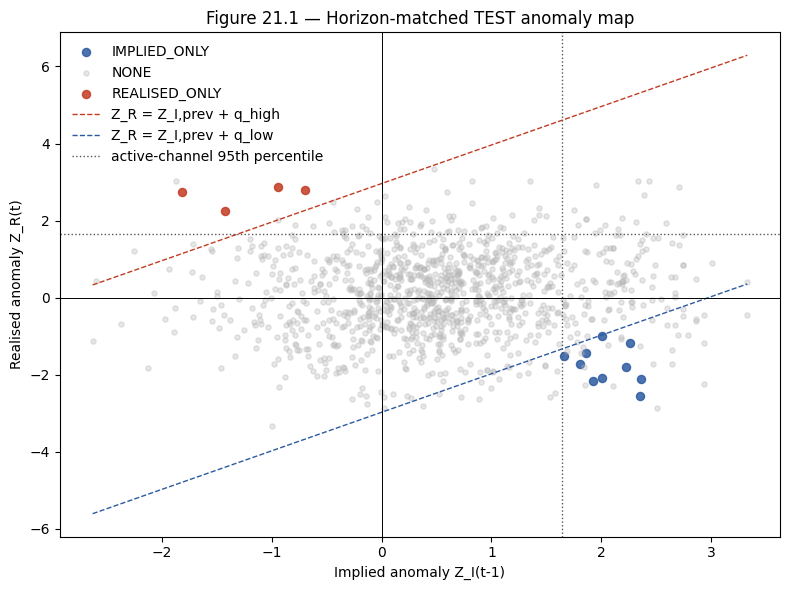

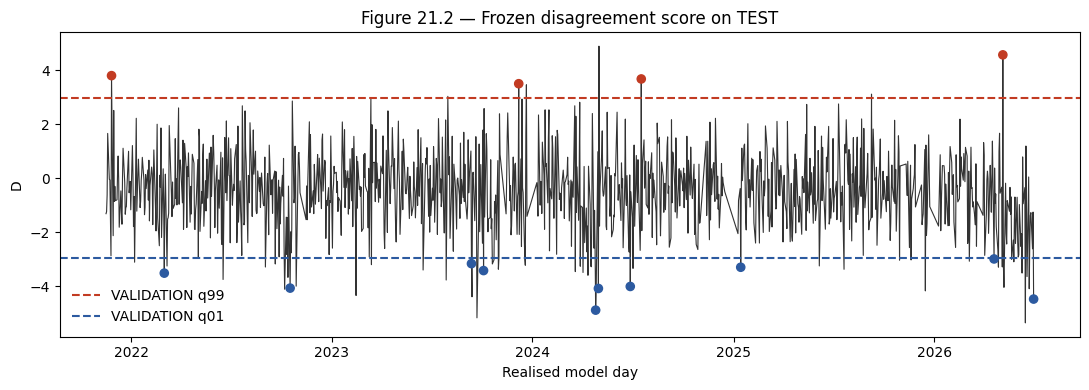

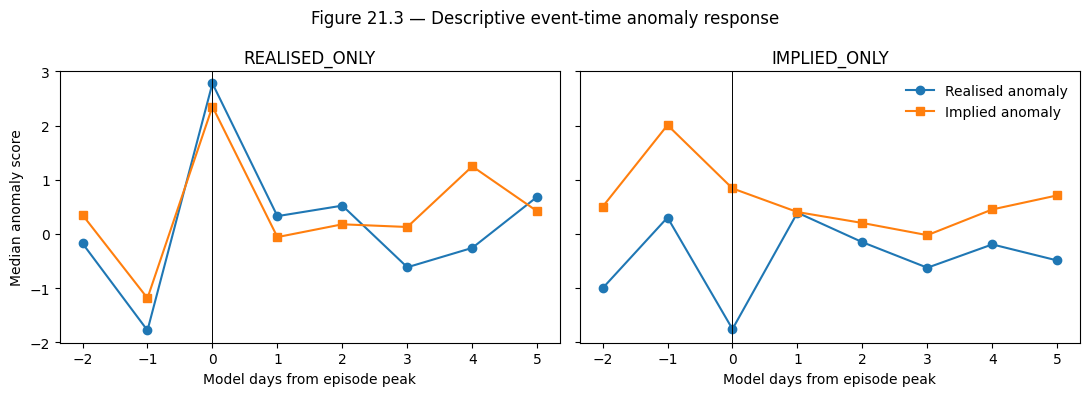

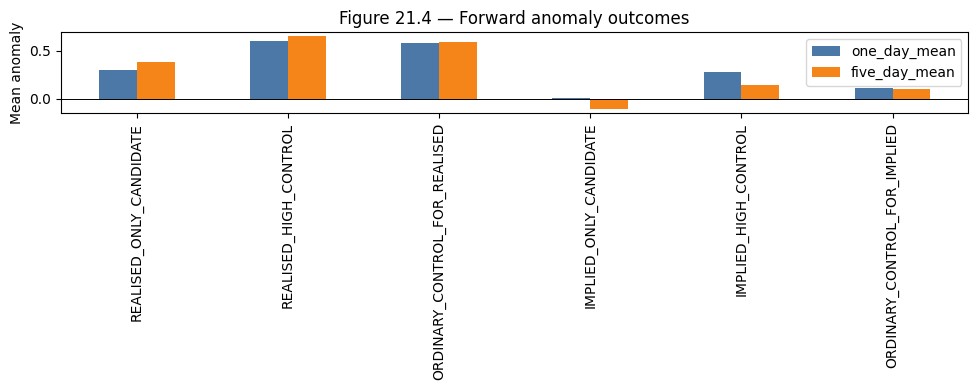

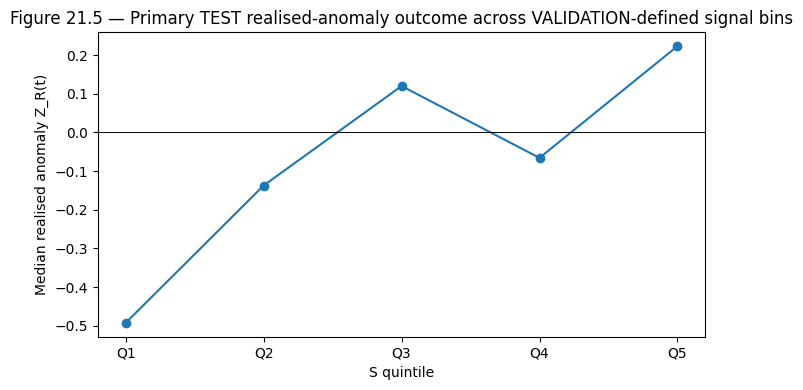

In [40]:
plt.style.use("default")
candidate_colors = {"NONE":"#b8b8b8","REALISED_ONLY":"#c23b22","IMPLIED_ONLY":"#2c5aa0"}

fig, ax = plt.subplots(figsize=(8,6))
for kind, group in test_scores.groupby("candidate_type"):
    ax.scatter(group["Z_I_prev"], group["Z_R"], s=34 if kind!="NONE" else 14,
               alpha=.85 if kind!="NONE" else .35, c=candidate_colors[kind], label=kind)
geometry_x = np.linspace(test_scores["Z_I_prev"].min(), test_scores["Z_I_prev"].max(), 200)
ax.plot(geometry_x, geometry_x + q_high, color="#c23b22", ls="--", lw=1, label="Z_R = Z_I,prev + q_high")
ax.plot(geometry_x, geometry_x + q_low, color="#2c5aa0", ls="--", lw=1, label="Z_R = Z_I,prev + q_low")
active_z = norm.ppf(ACTIVE_THRESHOLD)
ax.axhline(active_z, color="#555555", ls=":", lw=1, label="active-channel 95th percentile")
ax.axvline(active_z, color="#555555", ls=":", lw=1)
ax.axhline(0,color="black",lw=.7); ax.axvline(0,color="black",lw=.7)
ax.set(xlabel="Implied anomaly Z_I(t-1)",ylabel="Realised anomaly Z_R(t)",
       title="Figure 21.1 — Horizon-matched TEST anomaly map")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(FIGURES/"21_figure_21_1_anomaly_map.png",dpi=180); plt.show()

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(test_scores["realised_model_day"],test_scores["D"],color="#333333",lw=.8)
ax.axhline(q_high,color="#c23b22",ls="--",label="VALIDATION q99")
ax.axhline(q_low,color="#2c5aa0",ls="--",label="VALIDATION q01")
peaks=set(episodes["peak_day"]) if len(episodes) else set()
pk=test_scores.loc[test_scores["realised_model_day"].isin(peaks)]
ax.scatter(pk["realised_model_day"],pk["D"],c=pk["candidate_type"].map(candidate_colors),s=35,zorder=3)
ax.set(title="Figure 21.2 — Frozen disagreement score on TEST",ylabel="D",xlabel="Realised model day")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(FIGURES/"21_figure_21_2_disagreement_time.png",dpi=180); plt.show()

event_time=[]
for row in episodes.itertuples(index=False):
    for h in range(-2,6):
        idx=row.canonical_index+h
        hit=daily.loc[daily["canonical_index"].eq(idx)]
        if len(hit): event_time.append({"candidate_type":row.candidate_type,"horizon":h,
                                        "Z_R":hit["Z_R"].iloc[0],"Z_I":hit["Z_I"].iloc[0]})
event_time=pd.DataFrame(event_time)
fig, axes=plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax,kind in zip(axes,["REALISED_ONLY","IMPLIED_ONLY"]):
    g=event_time.loc[event_time["candidate_type"].eq(kind)] if len(event_time) else pd.DataFrame()
    if len(g):
        m=g.groupby("horizon")[["Z_R","Z_I"]].median()
        ax.plot(m.index,m["Z_R"],marker="o",label="Realised anomaly")
        ax.plot(m.index,m["Z_I"],marker="s",label="Implied anomaly")
    ax.axvline(0,color="black",lw=.7);ax.set(title=kind,xlabel="Model days from episode peak")
axes[0].set_ylabel("Median anomaly score");axes[1].legend(frameon=False)
fig.suptitle("Figure 21.3 — Descriptive event-time anomaly response");fig.tight_layout()
fig.savefig(FIGURES/"21_figure_21_3_event_time_response.png",dpi=180);plt.show()

fig,ax=plt.subplots(figsize=(10,4))
plot_forward=forward_information.set_index("analysis_group")[["one_day_mean","five_day_mean"]]
plot_forward.plot(kind="bar",ax=ax,color=["#4c78a8","#f58518"])
ax.axhline(0,color="black",lw=.7);ax.set(title="Figure 21.4 — Forward anomaly outcomes",ylabel="Mean anomaly",xlabel="")
fig.tight_layout();fig.savefig(FIGURES/"21_figure_21_4_forward_information.png",dpi=180);plt.show()

fig,ax=plt.subplots(figsize=(7,4))
ax.plot(quintile_summary["validation_defined_quintile"].astype(str),quintile_summary["primary_median_Z_R"],marker="o")
ax.axhline(0,color="black",lw=.7);ax.set(title="Figure 21.5 — Primary TEST realised-anomaly outcome across VALIDATION-defined signal bins",
                                       xlabel="S quintile", ylabel="Median realised anomaly Z_R(t)")
fig.tight_layout();fig.savefig(FIGURES/"21_figure_21_5_signal_bins.png",dpi=180);plt.show()

## 16. Compact in-memory reference tables

These concise tables collect detector settings, episodes, forward diagnostics, and signal summaries after the underlying scientific calculations have already been shown in context. Canonical CSV serialization remains deferred to the final atomic export cell.


In [41]:
table_21_1 = pd.DataFrame([{
    "flexible_models": " | ".join(FLEXIBLE_MODELS),
    "minimum_model_support": MIN_MODEL_SUPPORT,
    "validation_detector_n": len(validation_detector),
    "active_channel_percentile": ACTIVE_THRESHOLD,
    "q_low": q_low, "q_high": q_high, "S_cheap": S_cheap, "S_rich": S_rich,
    "primary_horizon": 1, "secondary_horizon": 5,
    "event_exclusion": "six frozen families on R_t or I_(t-1) target day",
}])
table_21_2 = episodes.copy()
table_21_3 = forward_information.assign(result_family="BEHAVIOUR_AND_RESOLUTION")
signal_primary_table = signal_summary[[
    "signal_group", "n", "primary_mean_Z_R", "primary_median_Z_R",
    "primary_mean_P_R", "primary_median_P_R", "primary_P_R_ge_0_95_rate",
    "primary_mean_Z_R_ci_low", "primary_mean_Z_R_ci_high",
    "primary_median_Z_R_ci_low", "primary_median_Z_R_ci_high",
    "primary_P_R_ge_0_95_rate_ci_low", "primary_P_R_ge_0_95_rate_ci_high",
    "bootstrap_valid_replicates", "bootstrap_valid_fraction",
]].assign(result_family="EX_ANTE_SIGNAL_PRIMARY")
signal_secondary_table = signal_summary[[
    "signal_group", "secondary_n_Y", "secondary_mean_Y", "secondary_median_Y",
    "secondary_median_R_over_I_prev", "secondary_directional_hit_rate",
    "secondary_mean_Y_ci_low", "secondary_mean_Y_ci_high",
    "secondary_median_Y_ci_low", "secondary_median_Y_ci_high",
    "secondary_directional_hit_rate_ci_low", "secondary_directional_hit_rate_ci_high",
]].assign(result_family="EX_ANTE_SIGNAL_SECONDARY")

run_metadata = pd.DataFrame([{
    "notebook": "21_empirical_hidden_event_discovery_and_signal_synthesis.ipynb",
    "upstream_ratios": "20_api_ordinary_response_ratios.csv",
    "event_alignment_version": FINAL_ALIGNMENT,
    "same_model_day_event_mapping": True,
    "bloomberg_snapshot_time_identified": False,
    "upstream_ordinary_ratio_contract": "EVENT_UNAWARE_ADMISSIBLE_WITH_RAW_DIAGNOSTICS",
    "primary_detector_ratio": "ordinary_response_ratio = actual / admissible ordinary background",
    "raw_ratio_role": "DIAGNOSTIC_ONLY",
    "frozen_floor_source": "UPSTREAM_N17_N20",
    "floors_recalibrated_in_n21": False,
    "ordinary_response_detector_input": True,
    "dynamic_detector_lock": True,
    "upstream_models": " | ".join(FLEXIBLE_MODELS),
    "cdf_calibration_sample": "VALIDATION_ONLY",
    "threshold_calibration_sample": "VALIDATION_ONLY",
    "test_role": "EVALUATION_ONLY",
    "pairing": "previous canonical model-day row",
    "models_refit": False, "models_reselected": False,
    "calendar_used_after_classification": True,
    "forward_horizons": "exact canonical t+1 and fixed t+1...t+5",
    "exercise_7a_controls": "independent directional masks; dual-high allowed",
    "exercise_7b_primary_outcome": "Z_R and P_R; Y secondary economic diagnostic",
    "exercise_7b_bootstrap": "full TEST canonical chronology moving blocks, length 5, then group statistics",
    "upstream_files_modified": False,
    "bootstrap_reps": BOOTSTRAP_REPS, "bootstrap_seed": BOOTSTRAP_SEED,
}])

# Core tables remain in memory until final closure and atomic export.

display(table_21_1)
display(table_21_2)
display(table_21_3)
display(signal_primary_table)
display(signal_secondary_table)

,flexible_models,minimum_model_support,validation_detector_n,active_channel_percentile,q_low,q_high,S_cheap,S_rich,primary_horizon,secondary_horizon,event_exclusion
0,RF | GB | MLP | TRANSFORMER,3,659,0.95,-2.975392,2.961641,-0.262306,0.329397,1,5,six frozen families on R_t or I_(t-1) target day


,episode_id,candidate_type,start_day,end_day,n_days,peak_day,implied_reference_day,peak_D,P_R,P_I_prev,...,n_Z_R_next5,n_Z_I_next5,implied_catches_up_same_day,implied_catches_up_next_day,realised_materialises_next_day,possible_timing_or_delayed_response,n_models_flagging_same_direction,models_flagging_same_direction,model_agreement_fraction,model_agreement_label
0,E21_001,REALISED_ONLY,2021-11-26,2021-11-26,1,2021-11-26,2021-11-25,3.802976,0.997885,0.172967,...,5,5,True,False,False,True,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
1,E21_002,IMPLIED_ONLY,2022-03-02,2022-03-02,1,2022-03-02,2022-03-01,-3.522530,0.042724,0.964276,...,5,5,False,False,False,False,3,GB | MLP | RF,0.75,STRONG_3_OF_4
2,E21_003,IMPLIED_ONLY,2022-10-17,2022-10-17,1,2022-10-17,2022-10-14,-4.077315,0.015651,0.972830,...,5,5,False,False,False,False,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
3,E21_004,IMPLIED_ONLY,2023-09-12,2023-09-12,1,2023-09-12,2023-09-11,-3.170094,0.065990,0.951919,...,5,5,False,False,False,False,2,GB | MLP,0.50,MODERATE_2_OF_4
4,E21_005,IMPLIED_ONLY,2023-10-04,2023-10-04,1,2023-10-04,2023-10-03,-3.427229,0.121827,0.988131,...,5,5,False,False,False,False,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
5,E21_006,REALISED_ONLY,2023-12-07,2023-12-07,1,2023-12-07,2023-12-06,3.503448,0.997462,0.241562,...,5,5,True,False,False,True,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
6,E21_007,IMPLIED_ONLY,2024-04-25,2024-04-25,1,2024-04-25,2024-04-24,-4.894560,0.005499,0.990659,...,5,5,False,False,False,False,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
7,E21_008,IMPLIED_ONLY,2024-04-30,2024-04-30,1,2024-04-30,2024-04-29,-4.091033,0.018613,0.977665,...,5,5,False,False,True,True,3,GB | MLP | TRANSFORMER,0.75,STRONG_3_OF_4
8,E21_009,IMPLIED_ONLY,2024-06-27,2024-06-27,1,2024-06-27,2024-06-26,-4.016639,0.036379,0.986868,...,5,5,False,False,False,False,4,GB | MLP | RF | TRANSFORMER,1.00,HIGH_4_OF_4
9,E21_010,REALISED_ONLY,2024-07-17,2024-07-17,1,2024-07-17,2024-07-16,3.679674,0.987733,0.076212,...,5,5,True,False,False,True,3,MLP | RF | TRANSFORMER,0.75,STRONG_3_OF_4


,analysis_group,analysis_side,mask_column,n,n_one_day,n_five_day,forward_channel,one_day_mean,one_day_median,five_day_mean,five_day_median,mean_convergence,one_day_ci_low,one_day_ci_high,exploratory_small_sample,result_family
0,REALISED_ONLY_CANDIDATE,REALISED,is_realised_only_candidate,4,4,4,I,0.298499,-0.059345,0.380696,0.388185,-1.540890,-0.244633,1.129446,True,BEHAVIOUR_AND_RESOLUTION
1,REALISED_HIGH_CONTROL,REALISED,is_realised_high_control,34,34,34,I,0.599421,0.504060,0.653065,0.695643,-0.331713,0.294063,0.898896,False,BEHAVIOUR_AND_RESOLUTION
2,ORDINARY_CONTROL_FOR_REALISED,REALISED,is_ordinary_control,584,584,566,I,0.584499,0.526030,0.587554,0.597144,0.231184,0.506935,0.661282,False,BEHAVIOUR_AND_RESOLUTION
3,IMPLIED_ONLY_CANDIDATE,IMPLIED,is_implied_only_candidate,10,9,9,R,0.007266,0.391495,-0.111372,-0.106712,-1.480169,-0.943903,1.051816,False,BEHAVIOUR_AND_RESOLUTION
4,IMPLIED_HIGH_CONTROL,IMPLIED,is_implied_high_control,34,34,33,R,0.278519,0.379732,0.137677,0.229555,-0.501444,-0.058078,0.605033,False,BEHAVIOUR_AND_RESOLUTION
5,ORDINARY_CONTROL_FOR_IMPLIED,IMPLIED,is_ordinary_control,584,581,563,R,0.108914,0.122242,0.101515,0.214442,0.231184,0.009873,0.200634,False,BEHAVIOUR_AND_RESOLUTION


,signal_group,n,primary_mean_Z_R,primary_median_Z_R,primary_mean_P_R,primary_median_P_R,primary_P_R_ge_0_95_rate,primary_mean_Z_R_ci_low,primary_mean_Z_R_ci_high,primary_median_Z_R_ci_low,primary_median_Z_R_ci_high,primary_P_R_ge_0_95_rate_ci_low,primary_P_R_ge_0_95_rate_ci_high,bootstrap_valid_replicates,bootstrap_valid_fraction,result_family
0,IMPLIED_CHEAP,10,-0.548904,-0.725808,0.323124,0.234183,0.000000,-0.903578,0.088807,-0.992431,-0.108501,0.000000,0.000000,4999,0.9998,EX_ANTE_SIGNAL_PRIMARY
1,IMPLIED_RICH,325,0.153041,0.139353,0.543099,0.555415,0.095385,0.017785,0.294717,0.007058,0.359819,0.065742,0.126936,5000,1.0000,EX_ANTE_SIGNAL_PRIMARY
2,NEUTRAL,846,0.058879,0.106127,0.520089,0.542259,0.061466,-0.026519,0.142618,-0.041365,0.212597,0.045773,0.078795,5000,1.0000,EX_ANTE_SIGNAL_PRIMARY


,signal_group,secondary_n_Y,secondary_mean_Y,secondary_median_Y,secondary_median_R_over_I_prev,secondary_directional_hit_rate,secondary_mean_Y_ci_low,secondary_mean_Y_ci_high,secondary_median_Y_ci_low,secondary_median_Y_ci_high,secondary_directional_hit_rate_ci_low,secondary_directional_hit_rate_ci_high,result_family
0,IMPLIED_CHEAP,10,-0.265312,-0.370534,0.690556,0.200000,-0.510817,0.144843,-0.512351,0.008466,0.000000,0.500000,EX_ANTE_SIGNAL_SECONDARY
1,IMPLIED_RICH,325,-0.587314,-0.585796,0.556663,0.803077,-0.681850,-0.490665,-0.667029,-0.500173,0.755814,0.846851,EX_ANTE_SIGNAL_SECONDARY
2,NEUTRAL,846,-0.414333,-0.391021,0.676367,NaN,-0.469596,-0.358824,-0.469812,-0.330533,NaN,NaN,EX_ANTE_SIGNAL_SECONDARY


## 17. Reproducibility checks before external validation

The checks below verify the frozen detector, canonical timing, signal construction, support conditions, and robustness objects before the calibration-transfer and external-validation summaries are constructed.


In [42]:
# Frozen-design and final-correction assertions.
assert not test_scores["sample_split"].eq("train").any()
assert set(validation_detector["sample_split"]) == {"validation"}
assert thresholds.loc[0, "cdf_sample"] == "VALIDATION_ONLY"
assert panel["previous_model_day"].equals(panel["model_day"].shift(1))
assert panel["next_model_day"].equals(panel["model_day"].shift(-1))
assert pairs["sample_split"].eq(pairs["previous_sample_split"]).all()
assert not test_scores.loc[test_scores["candidate_type"].ne("NONE"), "is_known_primary_event_pair"].any()
assert run_metadata.loc[0, "calendar_used_after_classification"]
assert pairs["n_models_R"].ge(3).all() and pairs["n_models_I_prev"].ge(3).all()
assert not run_metadata.loc[0, "models_refit"] and not run_metadata.loc[0, "models_reselected"]
assert not run_metadata.loc[0, "upstream_files_modified"]
assert np.allclose(
    ratio_percentiles["response_ratio"],
    ratio_percentiles["actual"] / ratio_percentiles["background_forecast"],
    rtol=1e-12, atol=1e-14,
)
assert signal["sample_split"].eq(signal["previous_sample_split"]).all()
assert signal["n_models"].ge(3).all()
assert np.allclose(
    signal.loc[signal["Y"].notna(), "Y"],
    np.log(signal.loc[signal["Y"].notna(), "R"] / signal.loc[signal["Y"].notna(), "I_prev"]),
)
assert not np.isinf(test_scores.select_dtypes(include=[np.number])).any().any()
assert not np.isinf(signal_test.select_dtypes(include=[np.number])).any().any()
assert episodes["episode_id"].is_unique
assert (annotations.loc[annotations["annotation_status"].eq("MULTIPLE_EVENTS"), "n_exact_coherent_families"] > 1).all()
assert (annotations.loc[annotations["n_exact_coherent_families"].le(1), "annotation_status"] != "MULTIPLE_EVENTS").all()

one_day = test_eval.loc[test_eval["one_day_model_day"].notna(), ["realised_model_day", "one_day_model_day"]]
positions = panel.set_index("model_day")["canonical_index"]
assert (one_day["one_day_model_day"].map(positions).to_numpy()
        == one_day["realised_model_day"].map(positions).to_numpy() + 1).all()
for h in range(1, 6):
    valid_h = daily[f"model_day_plus_{h}"].notna()
    assert (daily.loc[valid_h, f"model_day_plus_{h}"].map(positions).to_numpy()
            == daily.loc[valid_h, "canonical_index"].to_numpy() + h).all()
assert daily["n_Z_R_next5"].le(5).all() and daily["n_Z_I_next5"].le(5).all()

primary_7a_masks = [
    "is_realised_only_candidate", "is_implied_only_candidate",
    "is_realised_high_control", "is_implied_high_control", "is_ordinary_control",
]
assert not test_eval.loc[test_eval[primary_7a_masks].any(axis=1), "is_known_primary_event_pair"].any()
assert test_eval.loc[test_eval["is_realised_high_control"], "P_R"].ge(ACTIVE_THRESHOLD).all()
assert test_eval.loc[test_eval["is_implied_high_control"], "P_I_prev"].ge(ACTIVE_THRESHOLD).all()
assert (
    test_eval.loc[test_eval["is_ordinary_control"], "P_R"].lt(ACTIVE_THRESHOLD)
    & test_eval.loc[test_eval["is_ordinary_control"], "P_I_prev"].lt(ACTIVE_THRESHOLD)
).all()
assert test_eval["is_dual_high_control"].equals(
    test_eval["is_realised_high_control"] & test_eval["is_implied_high_control"]
)

realised_eps = episodes["candidate_type"].eq("REALISED_ONLY")
assert episodes.loc[realised_eps, "implied_catches_up_same_day"].equals(
    (episodes.loc[realised_eps, "P_I_same"].ge(ACTIVE_THRESHOLD)).rename("implied_catches_up_same_day")
)
assert {"primary_mean_Z_R", "primary_median_Z_R", "primary_mean_P_R",
        "primary_P_R_ge_0_95_rate"}.issubset(signal_summary.columns)
assert {"secondary_mean_Y", "secondary_median_Y", "secondary_directional_hit_rate"}.issubset(signal_summary.columns)
assert BOOTSTRAP_REPS == 5_000 and BOOTSTRAP_SEED == 21 and BLOCK_LENGTH == 5
assert signal_test_chronology["canonical_index"].diff().dropna().eq(1).all()
assert signal_summary["bootstrap_valid_replicates"].between(0, BOOTSTRAP_REPS).all()
assert signal_summary["bootstrap_valid_fraction"].between(0, 1).all()
assert "full TEST canonical chronology" in run_metadata.loc[0, "exercise_7b_bootstrap"]
assert candidate_agreement["n_models_flagging_same_direction"].between(0, 4).all()
assert set(candidate_agreement["model_agreement_label"]).issubset(
    {"HIGH_4_OF_4", "STRONG_3_OF_4", "MODERATE_2_OF_4", "CONSENSUS_ONLY_OR_WEAK"}
)
assert np.isfinite(q_low) and np.isfinite(q_high)
assert np.isfinite(S_cheap) and np.isfinite(S_rich)

n_primary_days = len(candidate_days)
n_realised = int(episodes["candidate_type"].eq("REALISED_ONLY").sum())
n_implied = int(episodes["candidate_type"].eq("IMPLIED_ONLY").sum())
n_exact = int(episodes["n_exact_coherent_families"].gt(0).sum()) if len(episodes) else 0
n_multiple = int(episodes["annotation_status"].eq("MULTIPLE_EVENTS").sum()) if len(episodes) else 0
n_unexplained = int(episodes["annotation_status"].eq("NO_CALENDAR_MATCH").sum()) if len(episodes) else 0
n_same = int(episodes.loc[realised_eps, "implied_catches_up_same_day"].sum())
n_next = int(episodes.loc[realised_eps, "implied_catches_up_next_day"].sum())
n_materialise = int(episodes.loc[episodes["candidate_type"].eq("IMPLIED_ONLY"), "realised_materialises_next_day"].sum())
sig = signal_summary.set_index("signal_group")
rich, neutral, cheap = sig.loc["IMPLIED_RICH"], sig.loc["NEUTRAL"], sig.loc["IMPLIED_CHEAP"]
cc = control_counts.iloc[0]
monotonic = bool(
    quintile_summary["primary_median_Z_R"].dropna().is_monotonic_increasing
    or quintile_summary["primary_median_Z_R"].dropna().is_monotonic_decreasing
)

display(Markdown(f"""
### Final corrected empirical summary

**Exercise 6.** The unchanged detector yields **{n_primary_days} primary candidate days**, collapsed into **{n_realised} REALISED_ONLY** and **{n_implied} IMPLIED_ONLY** TEST episodes. Agreement at primary candidate days is {agreement_counts["HIGH_4_OF_4"]} high (4/4), {agreement_counts["STRONG_3_OF_4"]} strong (3/4), {agreement_counts["MODERATE_2_OF_4"]} moderate (2/4), and {agreement_counts["CONSENSUS_ONLY_OR_WEAK"]} weak (0/1). Post-discovery calendar matching finds {n_exact} exact coherent-family episode matches, including {n_multiple} with multiple distinct families, and {n_unexplained} with no match.

**Timing.** Among REALISED_ONLY episodes, {n_same} show same-day implied catch-up and {n_next} show next-day implied catch-up; {n_materialise} IMPLIED_ONLY episodes show next-day realised materialisation. These remain descriptive timing-consistent explanations, not reclassification rules.

**Behaviour and controls.** Independent directional masks give {cc["n_realised_high_controls"]} realised-high controls, {cc["n_implied_high_controls"]} implied-high controls, {cc["n_ordinary_controls"]} ordinary controls, and {cc["n_dual_high_controls"]} dual-high controls. All exclude known-primary pairs and use exact canonical t+1 and fixed t+1...t+5 windows; small candidate groups remain exploratory.

**Ex-ante signal-relevant diagnostic — primary outcome.** Mean/median realised anomaly Z_R is {rich["primary_mean_Z_R"]:.3f}/{rich["primary_median_Z_R"]:.3f} for IMPLIED_RICH, {neutral["primary_mean_Z_R"]:.3f}/{neutral["primary_median_Z_R"]:.3f} for NEUTRAL, and {cheap["primary_mean_Z_R"]:.3f}/{cheap["primary_median_Z_R"]:.3f} for IMPLIED_CHEAP. Their 95% full-chronology moving-block CIs for mean Z_R are [{rich["primary_mean_Z_R_ci_low"]:.3f}, {rich["primary_mean_Z_R_ci_high"]:.3f}], [{neutral["primary_mean_Z_R_ci_low"]:.3f}, {neutral["primary_mean_Z_R_ci_high"]:.3f}], and [{cheap["primary_mean_Z_R_ci_low"]:.3f}, {cheap["primary_mean_Z_R_ci_high"]:.3f}], with usable-replicate fractions {rich["bootstrap_valid_fraction"]:.3f}, {neutral["bootstrap_valid_fraction"]:.3f}, and {cheap["bootstrap_valid_fraction"]:.3f}. The validation-defined quintile medians are {"monotonic" if monotonic else "not strictly monotonic"} on TEST.

**Ex-ante signal-relevant diagnostic — secondary economic diagnostic.** Y = log(R_t / I_(t-1)) is reported only as the ex-post realised-versus-prior-implied spread. Because Y shares the frozen realised-background forecast algebraically with S, its directional hit rates are not independent evidence of predictive content.

No option-profitability or structural-causality claim is made.
"""))
print("Notebook 21 complete: final downstream corrections use untouched frozen validation-calibrated rules and TEST-only assessment.")


### Final corrected empirical summary

**Exercise 6.** The unchanged detector yields **14 primary candidate days**, collapsed into **4 REALISED_ONLY** and **10 IMPLIED_ONLY** TEST episodes. Agreement at primary candidate days is 8 high (4/4), 4 strong (3/4), 1 moderate (2/4), and 1 weak (0/1). Post-discovery calendar matching finds 13 exact coherent-family episode matches, including 11 with multiple distinct families, and 0 with no match.

**Timing.** Among REALISED_ONLY episodes, 3 show same-day implied catch-up and 0 show next-day implied catch-up; 1 IMPLIED_ONLY episodes show next-day realised materialisation. These remain descriptive timing-consistent explanations, not reclassification rules.

**Behaviour and controls.** Independent directional masks give 34 realised-high controls, 34 implied-high controls, 584 ordinary controls, and 3 dual-high controls. All exclude known-primary pairs and use exact canonical t+1 and fixed t+1...t+5 windows; small candidate groups remain exploratory.

**Ex-ante signal-relevant diagnostic — primary outcome.** Mean/median realised anomaly Z_R is 0.153/0.139 for IMPLIED_RICH, 0.059/0.106 for NEUTRAL, and -0.549/-0.726 for IMPLIED_CHEAP. Their 95% full-chronology moving-block CIs for mean Z_R are [0.018, 0.295], [-0.027, 0.143], and [-0.904, 0.089], with usable-replicate fractions 1.000, 1.000, and 1.000. The validation-defined quintile medians are not strictly monotonic on TEST.

**Ex-ante signal-relevant diagnostic — secondary economic diagnostic.** Y = log(R_t / I_(t-1)) is reported only as the ex-post realised-versus-prior-implied spread. Because Y shares the frozen realised-background forecast algebraically with S, its directional hit rates are not independent evidence of predictive content.

No option-profitability or structural-causality claim is made.


Notebook 21 complete: final downstream corrections use untouched frozen validation-calibrated rules and TEST-only assessment.


## 18. Calibration-transfer audit

Median consensus percentiles are medians of empirically calibrated model percentiles and need not themselves be Uniform(0,1). TEST rates are therefore benchmarked against the corresponding empirical VALIDATION rates, not a nominal 5% rule. The six fixed metrics include component conditions and the two joint detector conditions; chronological uncertainty uses five-model-day moving blocks with the frozen seed and repetitions.


In [43]:
# Defensive closure snapshots: appended validation work must not mutate the frozen detector.
closure_test_scores_snapshot = test_scores.copy(deep=True)
closure_candidate_days_snapshot = candidate_days.copy(deep=True)
closure_episodes_snapshot = episodes.copy(deep=True)
closure_validation_detector_snapshot = validation_detector.copy(deep=True)
closure_q_low, closure_q_high = float(q_low), float(q_high)

CALIBRATION_METRICS = [
    "P_R_GE_0_95", "P_I_PREV_GE_0_95", "D_GE_Q_HIGH", "D_LE_Q_LOW",
    "REALISED_ONLY_JOINT", "IMPLIED_ONLY_JOINT",
]

def calibration_metric_matrix(frame):
    p_r = frame["P_R"].ge(ACTIVE_THRESHOLD).to_numpy()
    p_i = frame["P_I_prev"].ge(ACTIVE_THRESHOLD).to_numpy()
    d_hi = frame["D"].ge(q_high).to_numpy()
    d_lo = frame["D"].le(q_low).to_numpy()
    return np.column_stack([p_r, p_i, d_hi, d_lo, d_hi & p_r, d_lo & p_i])

def complete_split_chronology(split):
    chronology = panel.loc[
        panel["sample_split"].eq(split), ["model_day", "canonical_index"]
    ].copy()
    detector = pairs[[
        "realised_model_day", "sample_split", "P_R", "P_I_prev", "D",
        "is_known_primary_event_pair",
    ]].rename(columns={"realised_model_day": "model_day", "sample_split": "detector_split"})
    chronology = chronology.merge(detector, on="model_day", how="left", validate="one_to_one")
    required = chronology[["P_R", "P_I_prev", "D"]].notna().all(axis=1)
    chronology["eligible_ordinary_detector"] = (
        chronology["detector_split"].eq(split)
        & chronology["is_known_primary_event_pair"].eq(False)
        & required
    )
    chronology = chronology.sort_values("canonical_index").reset_index(drop=True)
    assert chronology["canonical_index"].diff().dropna().eq(1).all()
    return chronology

def chronology_rate_bootstrap(chronology, seed):
    n = len(chronology)
    starts = np.arange(n - BLOCK_LENGTH + 1)
    positions = chronology["canonical_index"].to_numpy()
    assert BLOCK_LENGTH == 5 and BOOTSTRAP_REPS == 5_000
    assert all(np.all(np.diff(positions[s:s + BLOCK_LENGTH]) == 1) for s in starts)
    eligible = chronology["eligible_ordinary_detector"].to_numpy(bool)
    metrics = calibration_metric_matrix(chronology)
    rng = np.random.default_rng(seed)
    blocks_needed = int(np.ceil(n / BLOCK_LENGTH))
    draws = np.full((BOOTSTRAP_REPS, len(CALIBRATION_METRICS)), np.nan)
    for rep in range(BOOTSTRAP_REPS):
        selected_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sampled = np.concatenate([
            np.arange(s, s + BLOCK_LENGTH) for s in selected_starts
        ])[:n]
        eligible_sample = eligible[sampled]
        if eligible_sample.any():
            draws[rep] = metrics[sampled][eligible_sample].mean(axis=0)
    observed = metrics[eligible].mean(axis=0)
    return observed, draws, int(eligible.sum())

validation_chronology = complete_split_chronology("validation")
test_chronology_closure = complete_split_chronology("test")
validation_rates, validation_rate_draws, validation_n = chronology_rate_bootstrap(
    validation_chronology, BOOTSTRAP_SEED + 1601
)
test_rates, test_rate_draws, test_n = chronology_rate_bootstrap(
    test_chronology_closure, BOOTSTRAP_SEED + 1602
)

calibration_rows = []
for j, metric in enumerate(CALIBRATION_METRICS):
    val_lo, val_hi = bootstrap_ci(validation_rate_draws[:, j])
    test_lo, test_hi = bootstrap_ci(test_rate_draws[:, j])
    difference_draws = test_rate_draws[:, j] - validation_rate_draws[:, j]
    diff_lo, diff_hi = bootstrap_ci(difference_draws)
    calibration_rows.append({
        "metric": metric,
        "validation_n": validation_n,
        "validation_rate": validation_rates[j],
        "validation_95pct_ci_low": val_lo,
        "validation_95pct_ci_high": val_hi,
        "test_n": test_n,
        "test_rate": test_rates[j],
        "test_95pct_ci_low": test_lo,
        "test_95pct_ci_high": test_hi,
        "test_minus_validation": test_rates[j] - validation_rates[j],
        "difference_95pct_ci_low": diff_lo,
        "difference_95pct_ci_high": diff_hi,
        "primary_benchmark": "EMPIRICAL_VALIDATION",
        "secondary_nominal_reference": 0.01 if metric in {"D_GE_Q_HIGH", "D_LE_Q_LOW"} else np.nan,
    })
calibration_transfer_audit = pd.DataFrame(calibration_rows)
display(calibration_transfer_audit)

,metric,validation_n,validation_rate,validation_95pct_ci_low,validation_95pct_ci_high,test_n,test_rate,test_95pct_ci_low,test_95pct_ci_high,test_minus_validation,difference_95pct_ci_low,difference_95pct_ci_high,primary_benchmark,secondary_nominal_reference
0,P_R_GE_0_95,659,0.044006,0.028919,0.061034,663,0.057315,0.040784,0.074924,0.013309,-0.010408,0.036407,EMPIRICAL_VALIDATION,NaN
1,P_I_PREV_GE_0_95,659,0.024279,0.013534,0.036419,663,0.066365,0.047839,0.085203,0.042086,0.019417,0.063962,EMPIRICAL_VALIDATION,NaN
2,D_GE_Q_HIGH,659,0.010622,0.003204,0.018989,663,0.007541,0.001515,0.014432,-0.003081,-0.013197,0.006947,EMPIRICAL_VALIDATION,0.01
3,D_LE_Q_LOW,659,0.010622,0.003252,0.018519,663,0.028658,0.015015,0.042029,0.018035,0.002152,0.032872,EMPIRICAL_VALIDATION,0.01
4,REALISED_ONLY_JOINT,659,0.007587,0.001520,0.014815,663,0.006033,0.001441,0.012308,-0.001554,-0.010362,0.007352,EMPIRICAL_VALIDATION,NaN
5,IMPLIED_ONLY_JOINT,659,0.007587,0.001543,0.014535,663,0.015083,0.005908,0.024025,0.007496,-0.004359,0.017764,EMPIRICAL_VALIDATION,NaN


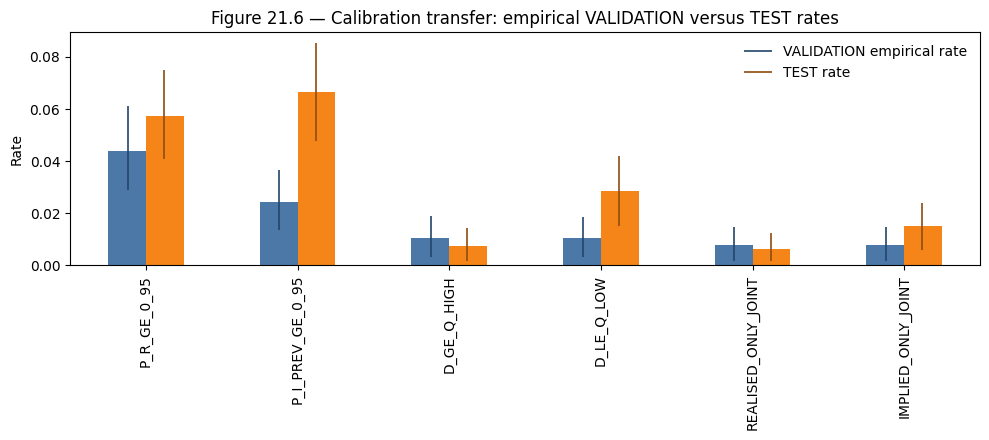

In [44]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_rates = calibration_transfer_audit.set_index("metric")[["validation_rate", "test_rate"]]
plot_rates.plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"])
for x, metric in enumerate(plot_rates.index):
    row = calibration_transfer_audit.loc[calibration_transfer_audit["metric"].eq(metric)].iloc[0]
    ax.vlines(x - 0.12, row["validation_95pct_ci_low"], row["validation_95pct_ci_high"], color="#24456b", lw=1.2)
    ax.vlines(x + 0.12, row["test_95pct_ci_low"], row["test_95pct_ci_high"], color="#8f4c0f", lw=1.2)
ax.set(title="Figure 21.6 — Calibration transfer: empirical VALIDATION versus TEST rates", ylabel="Rate", xlabel="")
ax.legend(["VALIDATION empirical rate", "TEST rate"], frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "21_figure_calibration_transfer.png", dpi=180)
plt.show()


## 19. Post-discovery external validation: Japanese MoF intervention

The detector, candidates, and episodes are locked before Ministry of Finance data are used. MoF is therefore an external post-discovery diagnostic, not an input to event identification. The primary window is ±5 canonical model days, with ±7 and ±10 sensitivities; campaigns use the pre-specified maximum five-calendar-day gap.

The exhaustive circular-shift upper-tail calculation is:

$$
p
=
\frac{
\#\{s:T_s\ge T_{\mathrm{obs}}\}
}{
1209
}.
$$

Results are interpreted as statistically unusual temporal association, not intervention prediction or causal identification.


In [45]:
MOF_RAW = MOF_RAW_PATH
assert MOF_RAW.exists()
with MOF_RAW.open("r", encoding="cp932") as handle:
    mof_lines = handle.readlines()
mof_header_row = next(
    i for i, line in enumerate(mof_lines)
    if "Year" in line and "Currency pairs" in line
)
mof_raw = pd.read_csv(MOF_RAW, encoding="cp932", skiprows=mof_header_row)
mof_raw["source_row_number"] = np.arange(mof_header_row + 2, mof_header_row + 2 + len(mof_raw))

year = pd.to_numeric(mof_raw["Year"], errors="coerce").ffill()
month_text = mof_raw["Month"].astype("string").replace({"": pd.NA}).ffill()
day = pd.to_numeric(mof_raw["Day"], errors="coerce")
amount = pd.to_numeric(
    mof_raw["金額(amount)"].astype("string").str.replace(",", "", regex=False),
    errors="coerce",
)
currency_direction = mof_raw["Currency pairs"].astype("string")
date_text = (
    year.round().astype("Int64").astype("string") + "-"
    + month_text + "-" + day.round().astype("Int64").astype("string")
)
intervention_date = pd.to_datetime(date_text, format="%Y-%b-%d", errors="coerce")
usd_jpy = (
    currency_direction.str.contains("US dollar", case=False, na=False)
    & currency_direction.str.contains("Japanese yen", case=False, na=False)
)
clean_rows = pd.DataFrame({
    "intervention_date": intervention_date,
    "amount_100m_yen": amount,
    "currency_direction": currency_direction,
    "source_row_number": mof_raw["source_row_number"],
}).loc[usd_jpy & intervention_date.notna() & amount.notna()].copy()
clean_rows["standardised_currency_direction"] = np.select(
    [
        clean_rows["currency_direction"].str.contains(r"US dollar \(sold\).*Japanese yen \(bought\)", case=False, regex=True),
        clean_rows["currency_direction"].str.contains(r"US dollar \(bought\).*Japanese yen \(sold\)", case=False, regex=True),
    ],
    ["USD_SOLD_JPY_BOUGHT", "USD_BOUGHT_JPY_SOLD"],
    default="USD_JPY_OTHER",
)

test_panel_closure = panel.loc[panel["sample_split"].eq("test")].sort_values("canonical_index").copy()
assert len(test_panel_closure) == 1209
assert test_panel_closure["canonical_index"].diff().dropna().eq(1).all()
test_start, test_end = test_panel_closure["model_day"].min(), test_panel_closure["model_day"].max()
clean_rows = clean_rows.loc[clean_rows["intervention_date"].between(test_start, test_end)].copy()
mof_interventions_clean = (
    clean_rows.groupby("intervention_date", as_index=False)
    .agg(
        amount_100m_yen=("amount_100m_yen", "sum"),
        currency_direction=("currency_direction", lambda s: " | ".join(sorted(set(s.astype(str))))),
        source_row_number=("source_row_number", "min"),
        standardised_currency_direction=("standardised_currency_direction", lambda s: " | ".join(sorted(set(s.astype(str))))),
    )
    .sort_values("intervention_date")
    .reset_index(drop=True)
)
assert len(mof_interventions_clean) > 0

test_dates = test_panel_closure["model_day"].to_numpy(dtype="datetime64[ns]")
test_indices = test_panel_closure["canonical_index"].to_numpy(int)
mapped_rows = []
for row in mof_interventions_clean.itertuples(index=False):
    target = np.datetime64(row.intervention_date)
    position = int(np.searchsorted(test_dates, target, side="left"))
    if position < len(test_dates) and test_dates[position] == target:
        status = "EXACT_SAME_LABELLED_MODEL_DAY"
    else:
        status = "NEXT_AVAILABLE_CANONICAL_MODEL_DAY"
        assert position < len(test_dates)
    mapped_rows.append({
        **row._asdict(),
        "mapped_model_day": pd.Timestamp(test_dates[position]),
        "mapped_canonical_index": int(test_indices[position]),
        "mapping_status": status,
    })
mof_interventions_clean = pd.DataFrame(mapped_rows)

mof_interventions_clean["new_campaign"] = (
    mof_interventions_clean["intervention_date"].diff().dt.days.fillna(999).gt(5)
)
mof_interventions_clean["campaign_number"] = mof_interventions_clean["new_campaign"].cumsum().astype(int)
mof_interventions_clean["campaign_id"] = (
    "MOF_CAMPAIGN_" + mof_interventions_clean["campaign_number"].astype(str).str.zfill(2)
)
mof_intervention_campaigns = (
    mof_interventions_clean.groupby("campaign_id", as_index=False)
    .agg(
        campaign_start_date=("intervention_date", "min"),
        campaign_end_date=("intervention_date", "max"),
        n_intervention_dates=("intervention_date", "nunique"),
        total_amount_100m_yen=("amount_100m_yen", "sum"),
    )
)
assert len(mof_intervention_campaigns) > 0
display(mof_interventions_clean)
display(mof_intervention_campaigns)

,intervention_date,amount_100m_yen,currency_direction,source_row_number,standardised_currency_direction,mapped_model_day,mapped_canonical_index,mapping_status,new_campaign,campaign_number,campaign_id
0,2022-09-22,28382,the US dollar (sold) the Japanese yen (bought),517,USD_SOLD_JPY_BOUGHT,2022-09-22,5058,EXACT_SAME_LABELLED_MODEL_DAY,True,1,MOF_CAMPAIGN_01
1,2022-10-21,56202,the US dollar (sold) the Japanese yen (bought),519,USD_SOLD_JPY_BOUGHT,2022-10-21,5079,EXACT_SAME_LABELLED_MODEL_DAY,True,2,MOF_CAMPAIGN_02
2,2022-10-24,7296,the US dollar (sold) the Japanese yen (bought),520,USD_SOLD_JPY_BOUGHT,2022-10-24,5080,EXACT_SAME_LABELLED_MODEL_DAY,False,2,MOF_CAMPAIGN_02
3,2024-04-29,59185,the US dollar (sold) the Japanese yen (bought),527,USD_SOLD_JPY_BOUGHT,2024-04-29,5475,EXACT_SAME_LABELLED_MODEL_DAY,True,3,MOF_CAMPAIGN_03
4,2024-05-01,38700,the US dollar (sold) the Japanese yen (bought),528,USD_SOLD_JPY_BOUGHT,2024-05-01,5477,EXACT_SAME_LABELLED_MODEL_DAY,False,3,MOF_CAMPAIGN_03
5,2024-07-11,31678,the US dollar (sold) the Japanese yen (bought),530,USD_SOLD_JPY_BOUGHT,2024-07-11,5528,EXACT_SAME_LABELLED_MODEL_DAY,True,4,MOF_CAMPAIGN_04
6,2024-07-12,23670,the US dollar (sold) the Japanese yen (bought),531,USD_SOLD_JPY_BOUGHT,2024-07-12,5529,EXACT_SAME_LABELLED_MODEL_DAY,False,4,MOF_CAMPAIGN_04
7,2026-04-30,62787,the US dollar (sold) the Japanese yen (bought),539,USD_SOLD_JPY_BOUGHT,2026-04-30,5998,EXACT_SAME_LABELLED_MODEL_DAY,True,5,MOF_CAMPAIGN_05
8,2026-05-04,7802,the US dollar (sold) the Japanese yen (bought),540,USD_SOLD_JPY_BOUGHT,2026-05-04,6000,EXACT_SAME_LABELLED_MODEL_DAY,False,5,MOF_CAMPAIGN_05
9,2026-05-06,46759,the US dollar (sold) the Japanese yen (bought),541,USD_SOLD_JPY_BOUGHT,2026-05-06,6002,EXACT_SAME_LABELLED_MODEL_DAY,False,5,MOF_CAMPAIGN_05


,campaign_id,campaign_start_date,campaign_end_date,n_intervention_dates,total_amount_100m_yen
0,MOF_CAMPAIGN_01,2022-09-22,2022-09-22,1,28382
1,MOF_CAMPAIGN_02,2022-10-21,2022-10-24,2,63498
2,MOF_CAMPAIGN_03,2024-04-29,2024-05-01,2,97885
3,MOF_CAMPAIGN_04,2024-07-11,2024-07-12,2,55348
4,MOF_CAMPAIGN_05,2026-04-30,2026-05-06,3,117348


,intervention_date,mapped_model_day,mapped_canonical_index,amount_100m_yen,currency_direction,campaign_id,nearest_episode_id,nearest_episode_type,nearest_episode_peak_day,signed_model_day_distance,absolute_model_day_distance,timing_relation,nearest_episode_tie,hit_within_5,hit_within_7,hit_within_10
0,2022-09-22,2022-09-22,5058,28382,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_01,E21_003,IMPLIED_ONLY,2022-10-17,17,17,POST_INTERVENTION,False,False,False,False
1,2022-10-21,2022-10-21,5079,56202,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_02,E21_003,IMPLIED_ONLY,2022-10-17,-4,4,PRE_INTERVENTION,False,True,True,True
2,2022-10-24,2022-10-24,5080,7296,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_02,E21_003,IMPLIED_ONLY,2022-10-17,-5,5,PRE_INTERVENTION,False,True,True,True
3,2024-04-29,2024-04-29,5475,59185,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_03,E21_008,IMPLIED_ONLY,2024-04-30,1,1,POST_INTERVENTION,False,True,True,True
4,2024-05-01,2024-05-01,5477,38700,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_03,E21_008,IMPLIED_ONLY,2024-04-30,-1,1,PRE_INTERVENTION,False,True,True,True
5,2024-07-11,2024-07-11,5528,31678,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_04,E21_010,REALISED_ONLY,2024-07-17,4,4,POST_INTERVENTION,False,True,True,True
6,2024-07-12,2024-07-12,5529,23670,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_04,E21_010,REALISED_ONLY,2024-07-17,3,3,POST_INTERVENTION,False,True,True,True
7,2026-04-30,2026-04-30,5998,62787,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_05,E21_013,REALISED_ONLY,2026-05-06,4,4,POST_INTERVENTION,False,True,True,True
8,2026-05-04,2026-05-04,6000,7802,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_05,E21_013,REALISED_ONLY,2026-05-06,2,2,POST_INTERVENTION,False,True,True,True
9,2026-05-06,2026-05-06,6002,46759,the US dollar (sold) the Japanese yen (bought),MOF_CAMPAIGN_05,E21_013,REALISED_ONLY,2026-05-06,0,0,CONTEMPORANEOUS,False,True,True,True


,window_model_days,specification_role,n_intervention_dates,date_hit_count,date_hit_rate,n_campaigns,campaign_hit_count,campaign_hit_rate,n_frozen_episodes,episode_overlap_count,...,date_hit_null_mean,date_hit_null_median,date_hit_null_q025,date_hit_null_q975,date_hit_exact_p_value,campaign_hit_null_mean,campaign_hit_null_median,campaign_hit_null_q025,campaign_hit_null_q975,campaign_hit_exact_p_value
0,5,PRIMARY,10,9,0.9,5,4,0.8,14,5,...,1.207610,0.0,0.0,6.0,0.002481,0.679074,0.0,0.0,3.0,0.007444
1,7,SENSITIVITY,10,9,0.9,5,4,0.8,14,5,...,1.571547,1.0,0.0,7.0,0.009926,0.848635,1.0,0.0,3.0,0.013234
2,10,SENSITIVITY,10,9,0.9,5,4,0.8,14,7,...,2.026468,2.0,0.0,7.8,0.018197,1.072787,1.0,0.0,4.0,0.027295


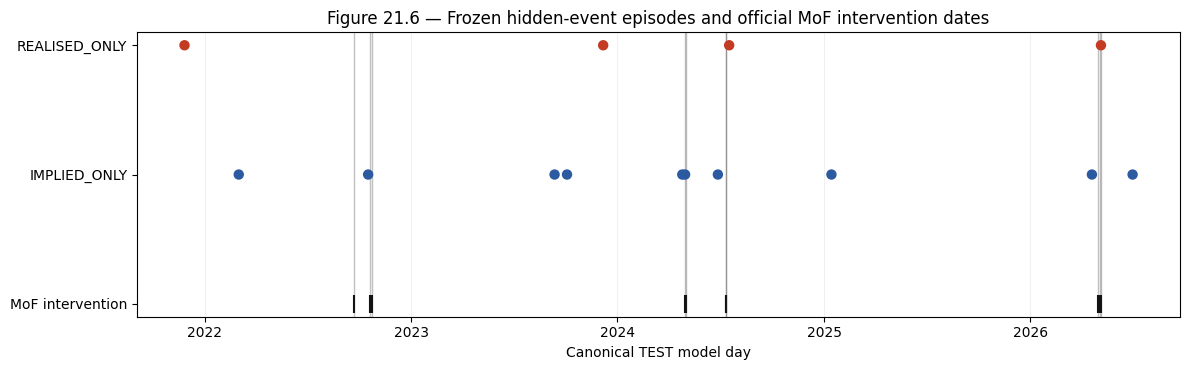

In [46]:
closure_episode_peaks = closure_episodes_snapshot[[
    "episode_id", "candidate_type", "peak_day", "canonical_index"
]].copy()
match_rows = []
for intervention in mof_interventions_clean.itertuples(index=False):
    distances = closure_episode_peaks["canonical_index"] - intervention.mapped_canonical_index
    absolute = distances.abs()
    minimum = int(absolute.min())
    tied = closure_episode_peaks.loc[absolute.eq(minimum)].sort_values(
        ["peak_day", "episode_id"]
    )
    chosen = tied.iloc[0]
    signed = int(chosen["canonical_index"] - intervention.mapped_canonical_index)
    relation = "PRE_INTERVENTION" if signed < 0 else "POST_INTERVENTION" if signed > 0 else "CONTEMPORANEOUS"
    match_rows.append({
        "intervention_date": intervention.intervention_date,
        "mapped_model_day": intervention.mapped_model_day,
        "mapped_canonical_index": intervention.mapped_canonical_index,
        "amount_100m_yen": intervention.amount_100m_yen,
        "currency_direction": intervention.currency_direction,
        "campaign_id": intervention.campaign_id,
        "nearest_episode_id": chosen["episode_id"],
        "nearest_episode_type": chosen["candidate_type"],
        "nearest_episode_peak_day": chosen["peak_day"],
        "signed_model_day_distance": signed,
        "absolute_model_day_distance": minimum,
        "timing_relation": relation,
        "nearest_episode_tie": len(tied) > 1,
        "hit_within_5": minimum <= 5,
        "hit_within_7": minimum <= 7,
        "hit_within_10": minimum <= 10,
    })
mof_intervention_matches = pd.DataFrame(match_rows)
WINDOWS = [5, 7, 10]
test_index_min = int(test_panel_closure["canonical_index"].min())
n_test = len(test_panel_closure)
episode_positions = closure_episode_peaks["canonical_index"].to_numpy(int) - test_index_min
intervention_positions = mof_interventions_clean["mapped_canonical_index"].to_numpy(int) - test_index_min
campaign_ids = mof_interventions_clean["campaign_id"].to_numpy(object)

null_rows = []
for shift in range(n_test):
    shifted_episode_positions = (episode_positions + shift) % n_test
    linear_distances = np.abs(
        intervention_positions[:, None] - shifted_episode_positions[None, :]
    )
    for window in WINDOWS:
        date_hits = (linear_distances <= window).any(axis=1)
        campaign_hits = {
            campaign_id: bool(date_hits[campaign_ids == campaign_id].any())
            for campaign_id in mof_intervention_campaigns["campaign_id"]
        }
        null_rows.append({
            "shift": shift,
            "window": window,
            "date_hit_count": int(date_hits.sum()),
            "campaign_hit_count": int(sum(campaign_hits.values())),
        })
mof_circular_shift_null = pd.DataFrame(null_rows)

summary_rows = []
for window in WINDOWS:
    hit_col = f"hit_within_{window}"
    date_hit = mof_intervention_matches[hit_col]
    hit_campaigns = mof_intervention_matches.loc[date_hit, "campaign_id"].nunique()
    episode_overlap = np.array([
        np.any(np.abs(intervention_positions - episode_position) <= window)
        for episode_position in episode_positions
    ])
    matched = mof_intervention_matches.loc[date_hit]
    null_window = mof_circular_shift_null.loc[mof_circular_shift_null["window"].eq(window)]
    observed_date_hits = int(date_hit.sum())
    observed_campaign_hits = int(hit_campaigns)
    summary_rows.append({
        "window_model_days": window,
        "specification_role": "PRIMARY" if window == 5 else "SENSITIVITY",
        "n_intervention_dates": len(mof_intervention_matches),
        "date_hit_count": observed_date_hits,
        "date_hit_rate": observed_date_hits / len(mof_intervention_matches),
        "n_campaigns": len(mof_intervention_campaigns),
        "campaign_hit_count": observed_campaign_hits,
        "campaign_hit_rate": observed_campaign_hits / len(mof_intervention_campaigns),
        "n_frozen_episodes": len(closure_episode_peaks),
        "episode_overlap_count": int(episode_overlap.sum()),
        "episode_overlap_rate": float(episode_overlap.mean()),
        "pre_intervention_matches": int(matched["timing_relation"].eq("PRE_INTERVENTION").sum()),
        "contemporaneous_matches": int(matched["timing_relation"].eq("CONTEMPORANEOUS").sum()),
        "post_intervention_matches": int(matched["timing_relation"].eq("POST_INTERVENTION").sum()),
        "date_hit_null_mean": null_window["date_hit_count"].mean(),
        "date_hit_null_median": null_window["date_hit_count"].median(),
        "date_hit_null_q025": null_window["date_hit_count"].quantile(.025),
        "date_hit_null_q975": null_window["date_hit_count"].quantile(.975),
        "date_hit_exact_p_value": float((null_window["date_hit_count"] >= observed_date_hits).mean()),
        "campaign_hit_null_mean": null_window["campaign_hit_count"].mean(),
        "campaign_hit_null_median": null_window["campaign_hit_count"].median(),
        "campaign_hit_null_q025": null_window["campaign_hit_count"].quantile(.025),
        "campaign_hit_null_q975": null_window["campaign_hit_count"].quantile(.975),
        "campaign_hit_exact_p_value": float((null_window["campaign_hit_count"] >= observed_campaign_hits).mean()),
    })
mof_intervention_validation_summary = pd.DataFrame(summary_rows)

display(mof_intervention_matches)
display(mof_intervention_validation_summary)

fig, ax = plt.subplots(figsize=(12, 3.8))
episode_y = closure_episode_peaks["candidate_type"].map({"IMPLIED_ONLY": 1, "REALISED_ONLY": 2})
episode_color = closure_episode_peaks["candidate_type"].map({"IMPLIED_ONLY": "#2c5aa0", "REALISED_ONLY": "#c23b22"})
ax.scatter(closure_episode_peaks["peak_day"], episode_y, c=episode_color, s=42, zorder=3)
for date in mof_interventions_clean["mapped_model_day"]:
    ax.axvline(date, color="#222222", alpha=.28, lw=1)
ax.scatter(mof_interventions_clean["mapped_model_day"], np.zeros(len(mof_interventions_clean)),
           marker="|", s=170, color="#111111", label="Official MoF intervention")
ax.set_yticks([0, 1, 2], ["MoF intervention", "IMPLIED_ONLY", "REALISED_ONLY"])
ax.set(xlabel="Canonical TEST model day",
       title="Figure 21.6 — Frozen hidden-event episodes and official MoF intervention dates")
ax.grid(axis="x", alpha=.18)
fig.tight_layout()
fig.savefig(FIGURES / "21_figure_21_6_mof_intervention_validation.png", dpi=180)
plt.show()

## 20. Exercise 7 — new information from the full empirical analysis

Exercise 7 synthesises the information gained across the frozen empirical pipeline. N16 established strong prior implied-to-realised predictive information while Q added weak/non-stable incremental information for R. N18 showed target-specific scheduled-event deviations from eventless backgrounds. N19 showed that the realised-target implied relation persists across flexible learners, while implied-target structure is more model-dependent.

Exercise 6 adds the observation that this ordinarily informative realised/implied relation can break sharply: realised-dominant states are extreme realised outcomes not already matched by prior implied activity, while implied-dominant states are elevated prior implied states not proportionately followed by realised extremity. The MoF analysis is external temporal association. Together these are predictive, descriptive, and economically interpretable findings—not structural causal identification.


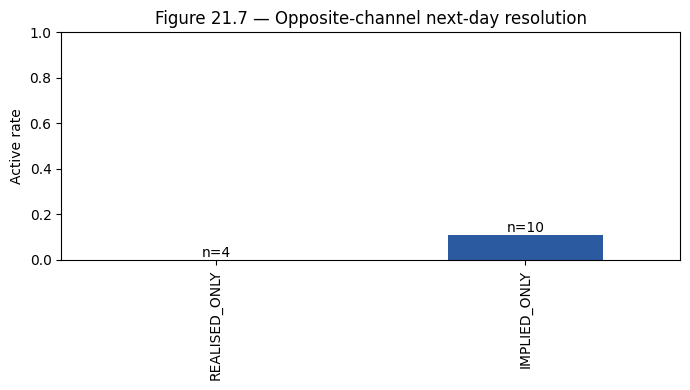

,information_block,evidence,interpretation,limitation,application_relevance
0,PREDICTIVE_STRUCTURE,Frozen N16/N19 results: prior implied variance...,Ordinary realised-variance dynamics normally c...,Predictive structure is not structural causal ...,Provides the ordinary benchmark from which cro...
1,KNOWN_EVENT_RESPONSE,Frozen N18/N19 event-weight outputs quantify t...,Scheduled-event responses contextualise labell...,Known-event weights are not used in the hidden...,Separates labelled scheduled-event evidence fr...
2,REALISED_ONLY_HIDDEN_STATES,Dynamic episodes: 4; strict fraction: 1.000; n...,Realised volatility departed sharply from an o...,Ex-post classification; timing diagnostics are...,A later application may only use the classific...
3,IMPLIED_ONLY_HIDDEN_STATES,Dynamic episodes: 10; strict fraction: 1.000; ...,Implied risk was unusually elevated relative t...,Possible economic mechanisms are interpretatio...,Motivates the separate ex-ante implied-versus-...
4,CALIBRATION_TRANSFER,REALISED_ONLY_JOINT: TEST−VALIDATION=-0.155% |...,Transfer is assessed against empirical VALIDAT...,Bootstrap intervals describe sampling uncertai...,Records stability of frozen pre-TEST calibration.
5,MOF_POST_DISCOVERY_VALIDATION,Primary ±5 canonical-day association: date p=0...,Any unusual association is external temporal v...,Not intervention prediction or causal identifi...,Diagnostic context only; not an application fe...
6,EX_ANTE_SIGNAL,TEST mean Z_R: rich=0.153; neutral=0.059; chea...,S uses only I_(t-1) and frozen R backgrounds a...,"No option threshold, PnL, or strategy paramete...",Ex-ante input for the later application notebook.


In [47]:
primary_mof_summary = mof_intervention_validation_summary.loc[
    mof_intervention_validation_summary["window_model_days"].eq(5)
].iloc[0]
strict_lookup = strict_cross_channel_summary.set_index("candidate_type")
resolution_lookup = channel_resolution_summary.set_index("candidate_type")
signal_lookup = signal_summary.set_index("signal_group")
joint_transfer = calibration_transfer_audit.loc[
    calibration_transfer_audit["metric"].isin(["REALISED_ONLY_JOINT", "IMPLIED_ONLY_JOINT"])
]
task7_information_synthesis = pd.DataFrame([
    {
        "information_block": "PREDICTIVE_STRUCTURE",
        "evidence": "Frozen N16/N19 results: prior implied variance is the strongest robust predictor for realised variance; flexible R models retain I and exclude Q.",
        "interpretation": "Ordinary realised-variance dynamics normally contain substantial prior-implied predictive information.",
        "limitation": "Predictive structure is not structural causal identification.",
        "application_relevance": "Provides the ordinary benchmark from which cross-channel dislocations depart.",
    },
    {
        "information_block": "KNOWN_EVENT_RESPONSE",
        "evidence": "Frozen N18/N19 event-weight outputs quantify target-specific deviations from eventless backgrounds for scheduled events.",
        "interpretation": "Scheduled-event responses contextualise labelled deviations; N21 examines unlabelled ordinary-dynamic departures.",
        "limitation": "Known-event weights are not used in the hidden-state detector.",
        "application_relevance": "Separates labelled scheduled-event evidence from hidden-state evidence.",
    },
    {
        "information_block": "REALISED_ONLY_HIDDEN_STATES",
        "evidence": f"Dynamic episodes: {int((episodes.candidate_type == 'REALISED_ONLY').sum())}; strict fraction: {strict_lookup.loc['REALISED_ONLY', 'strict_fraction'] if 'REALISED_ONLY' in strict_lookup.index else np.nan:.3f}; next-day opposite-channel active rate: {resolution_lookup.loc['REALISED_ONLY', 'opposite_channel_next_day_active_rate'] if 'REALISED_ONLY' in resolution_lookup.index else np.nan:.3f}.",
        "interpretation": "Realised volatility departed sharply from an ordinary relationship in which prior implied variance is normally informative.",
        "limitation": "Ex-post classification; timing diagnostics are descriptive.",
        "application_relevance": "A later application may only use the classification after model day t is observed.",
    },
    {
        "information_block": "IMPLIED_ONLY_HIDDEN_STATES",
        "evidence": f"Dynamic episodes: {int((episodes.candidate_type == 'IMPLIED_ONLY').sum())}; strict fraction: {strict_lookup.loc['IMPLIED_ONLY', 'strict_fraction'] if 'IMPLIED_ONLY' in strict_lookup.index else np.nan:.3f}; next-day realised active rate: {resolution_lookup.loc['IMPLIED_ONLY', 'opposite_channel_next_day_active_rate'] if 'IMPLIED_ONLY' in resolution_lookup.index else np.nan:.3f}.",
        "interpretation": "Implied risk was unusually elevated relative to ordinary dynamics without proportionately extreme subsequent realised volatility.",
        "limitation": "Possible economic mechanisms are interpretations, not identified mechanisms.",
        "application_relevance": "Motivates the separate ex-ante implied-versus-forecast signal.",
    },
    {
        "information_block": "CALIBRATION_TRANSFER",
        "evidence": " | ".join(f"{r.metric}: TEST−VALIDATION={r.test_minus_validation:+.3%}" for r in joint_transfer.itertuples(index=False)),
        "interpretation": "Transfer is assessed against empirical VALIDATION rates, with component and joint conditions distinguished.",
        "limitation": "Bootstrap intervals describe sampling uncertainty, not a reselected detector.",
        "application_relevance": "Records stability of frozen pre-TEST calibration.",
    },
    {
        "information_block": "MOF_POST_DISCOVERY_VALIDATION",
        "evidence": f"Primary ±5 canonical-day association: date p={primary_mof_summary.date_hit_exact_p_value:.4f}; campaign p={primary_mof_summary.campaign_hit_exact_p_value:.4f}; all 1209 circular shifts used.",
        "interpretation": "Any unusual association is external temporal validation after discovery.",
        "limitation": "Not intervention prediction or causal identification.",
        "application_relevance": "Diagnostic context only; not an application feature.",
    },
    {
        "information_block": "EX_ANTE_SIGNAL",
        "evidence": f"TEST mean Z_R: rich={signal_lookup.loc['IMPLIED_RICH', 'primary_mean_Z_R']:.3f}; neutral={signal_lookup.loc['NEUTRAL', 'primary_mean_Z_R']:.3f}; cheap={signal_lookup.loc['IMPLIED_CHEAP', 'primary_mean_Z_R']:.3f}.",
        "interpretation": "S uses only I_(t-1) and frozen R backgrounds available before R_t.",
        "limitation": "No option threshold, PnL, or strategy parameter is selected here.",
        "application_relevance": "Ex-ante input for the later application notebook.",
    },
])

# Production CSV export is intentionally deferred until after final closure.

fig, ax = plt.subplots(figsize=(7, 4))
plot_resolution = channel_resolution_summary.set_index("candidate_type")["opposite_channel_next_day_active_rate"]
plot_resolution.plot(kind="bar", ax=ax, color=["#c23b22", "#2c5aa0"])
for position, row in enumerate(channel_resolution_summary.itertuples(index=False)):
    value = row.opposite_channel_next_day_active_rate
    if np.isfinite(value):
        ax.text(position, value, f"n={row.n_episodes}", ha="center", va="bottom")
ax.set(title="Figure 21.7 — Opposite-channel next-day resolution", ylabel="Active rate", xlabel="")
ax.set_ylim(0, max(1.0, np.nanmax(channel_resolution_summary["opposite_channel_next_day_active_rate"]) * 1.15))
fig.tight_layout()
fig.savefig(FIGURES / "21_figure_channel_resolution.png", dpi=180)
plt.show()

display(task7_information_synthesis)


## 21. Application handoff

N21 does not implement a trading strategy. The subsequent application receives `21_application_state_panel.csv`, which distinguishes hidden states available after model day t from the ex-ante S diagnostic. Hidden-state timing is `AVAILABLE_AFTER_MODEL_DAY_T`; S timing is `EX_ANTE_BEFORE_R_T`; calendar and MoF labels remain `POST_DISCOVERY_DIAGNOSTIC_ONLY`. TRAIN application-facing signal labels are deliberately protected as `NOT_EVALUATED`.


In [48]:
# Application-ready state construction. Post-discovery labels are deliberately excluded from S_t.
pair_state = pairs[[
    "realised_model_day", "P_R", "Z_R", "P_I_prev", "Z_I_prev", "D", "n_models_R", "n_models_I_prev",
    "is_known_primary_event_pair",
]].rename(columns={"realised_model_day": "model_day"})
application_state_panel = panel[["model_day", "sample_split", "canonical_index", "next_model_day"]].merge(
    pair_state, on="model_day", how="left", validate="one_to_one"
).merge(
    signal[["model_day", "S", "signal_group", "validation_defined_quintile"]],
    on="model_day", how="left", validate="one_to_one"
)
state_candidates = candidate_days[[
    "realised_model_day", "candidate_type", "episode_id", "opposite_channel_active", "strict_cross_channel_dislocation",
]].rename(columns={"realised_model_day": "model_day"})
application_state_panel = application_state_panel.merge(
    state_candidates, on="model_day", how="left", validate="one_to_one"
)
state_agreement = test_scores[["realised_model_day", "model_agreement_label"]].rename(columns={"realised_model_day": "model_day"})
application_state_panel = application_state_panel.merge(state_agreement, on="model_day", how="left", validate="one_to_one")
application_state_panel["signal_threshold_source"] = "VALIDATION"
application_state_panel["signal_application_eligible"] = application_state_panel["sample_split"].isin(["validation", "test"])
application_state_panel["raw_S"] = application_state_panel["S"]
application_state_panel["signal_group_raw"] = application_state_panel["signal_group"].astype("string")
application_state_panel["validation_defined_quintile_raw"] = application_state_panel["validation_defined_quintile"].astype("string")
application_state_panel["signal_group"] = application_state_panel["signal_group_raw"].copy()
application_state_panel["validation_defined_quintile"] = application_state_panel["validation_defined_quintile_raw"].copy()
train_signal_rows = ~application_state_panel["signal_application_eligible"]
application_state_panel.loc[train_signal_rows, "signal_group"] = "NOT_EVALUATED"
application_state_panel.loc[train_signal_rows, "validation_defined_quintile"] = "NOT_EVALUATED"
application_state_panel["candidate_type"] = np.where(
    application_state_panel["sample_split"].eq("test"),
    application_state_panel["candidate_type"].fillna("NONE"),
    "NOT_EVALUATED",
)
application_state_panel["episode_id"] = application_state_panel["episode_id"].fillna("")
application_state_panel["opposite_channel_active"] = application_state_panel["opposite_channel_active"].fillna(False).astype(bool)
application_state_panel["strict_cross_channel_dislocation"] = application_state_panel["strict_cross_channel_dislocation"].fillna(False).astype(bool)
application_state_panel["model_agreement_label"] = application_state_panel["model_agreement_label"].fillna("NOT_PRIMARY_CANDIDATE")
application_state_panel["hidden_state_information_timing"] = "AVAILABLE_AFTER_MODEL_DAY_T"
application_state_panel["signal_information_timing"] = "EX_ANTE_BEFORE_R_T"
application_state_panel["diagnostic_information_role"] = "POST_DISCOVERY_DIAGNOSTIC"
application_state_panel["calendar_and_mof_role"] = "POST_DISCOVERY_DIAGNOSTIC_ONLY"


display(application_state_panel.head())


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_15944\3755319645.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  application_state_panel["opposite_channel_active"] = application_state_panel["opposite_channel_active"].fillna(False).astype(bool)
C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_15944\3755319645.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  application_state_panel["strict_cross_channel_dislocation"] = application_state_panel["strict_cross_channel_dislocation"].fillna(False).astype(bool)


,model_day,sample_split,canonical_index,next_model_day,P_R,Z_R,P_I_prev,Z_I_prev,D,n_models_R,...,model_agreement_label,signal_threshold_source,signal_application_eligible,raw_S,signal_group_raw,validation_defined_quintile_raw,hidden_state_information_timing,signal_information_timing,diagnostic_information_role,calendar_and_mof_role
0,2003-05-05,train,0,2003-05-06,NaN,NaN,NaN,NaN,NaN,NaN,...,NOT_PRIMARY_CANDIDATE,VALIDATION,False,NaN,<NA>,<NA>,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T,POST_DISCOVERY_DIAGNOSTIC,POST_DISCOVERY_DIAGNOSTIC_ONLY
1,2003-05-06,train,1,2003-05-07,NaN,NaN,NaN,NaN,NaN,NaN,...,NOT_PRIMARY_CANDIDATE,VALIDATION,False,NaN,<NA>,<NA>,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T,POST_DISCOVERY_DIAGNOSTIC,POST_DISCOVERY_DIAGNOSTIC_ONLY
2,2003-05-07,train,2,2003-05-08,NaN,NaN,NaN,NaN,NaN,NaN,...,NOT_PRIMARY_CANDIDATE,VALIDATION,False,NaN,<NA>,<NA>,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T,POST_DISCOVERY_DIAGNOSTIC,POST_DISCOVERY_DIAGNOSTIC_ONLY
3,2003-05-08,train,3,2003-05-09,NaN,NaN,NaN,NaN,NaN,NaN,...,NOT_PRIMARY_CANDIDATE,VALIDATION,False,NaN,<NA>,<NA>,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T,POST_DISCOVERY_DIAGNOSTIC,POST_DISCOVERY_DIAGNOSTIC_ONLY
4,2003-05-09,train,4,2003-05-12,NaN,NaN,NaN,NaN,NaN,NaN,...,NOT_PRIMARY_CANDIDATE,VALIDATION,False,NaN,<NA>,<NA>,AVAILABLE_AFTER_MODEL_DAY_T,EX_ANTE_BEFORE_R_T,POST_DISCOVERY_DIAGNOSTIC,POST_DISCOVERY_DIAGNOSTIC_ONLY


## 22. Closure, reproducibility checks, and atomic exports

Technical closure validates upstream provenance, dynamic candidate/episode locks, threshold and support rules, detector-consistent convergence, calibration bootstrap, MoF shifts, application timing labels, and the final readiness flag. Only after this closure does the deterministic atomic export cell serialize canonical N21 outputs.


In [49]:
validation_closure_metadata = pd.DataFrame([{
    "notebook": "21_empirical_hidden_event_discovery_and_signal_synthesis.ipynb",
    "detector_candidate_lock_signature": detector_candidate_lock_signature,
    "detector_episode_lock_signature": detector_episode_lock_signature,
    "upstream_alignment": FINAL_ALIGNMENT,
    "upstream_mode": "REUSE",
    "same_model_day_event_mapping": True,
    "bloomberg_snapshot_time_identified": False,
    "upstream_ordinary_ratio_contract": "EVENT_UNAWARE_ADMISSIBLE_WITH_RAW_DIAGNOSTICS",
    "primary_detector_ratio": "ordinary_response_ratio = actual / admissible ordinary background",
    "raw_ratio_role": "DIAGNOSTIC_ONLY",
    "frozen_floor_source": "UPSTREAM_N17_N20",
    "floors_recalibrated_in_n21": False,
    "n20_readiness_provenance": n20_readiness_provenance,
    "thresholds_recalibrated_on_test": False,
    "models_refit": False,
    "models_reselected": False,
    "linus_equation_5_used": False,
    "calibration_transfer_primary_benchmark": "EMPIRICAL_VALIDATION",
    "block_length": BLOCK_LENGTH,
    "bootstrap_reps": BOOTSTRAP_REPS,
    "mof_primary_window": 5,
    "mof_sensitivity_windows": "7 | 10",
    "circular_shift_null": f"all 1209 offsets of frozen {len(episodes)}-episode peak pattern",
    "circular_shift_exhaustive": True,
    "external_validation_role": "post-discovery temporal association, not causal identification",
}])
current_candidate_lock, current_candidate_signature = detector_signature(candidate_days, candidate_lock_columns)
current_episode_lock, current_episode_signature = detector_signature(episodes, episode_lock_columns)
pd.testing.assert_frame_equal(detector_candidate_lock, current_candidate_lock)
pd.testing.assert_frame_equal(detector_episode_lock, current_episode_lock)
assert current_candidate_signature == detector_candidate_lock_signature
assert current_episode_signature == detector_episode_lock_signature
assert set(candidate_days["candidate_type"]).issubset({"REALISED_ONLY", "IMPLIED_ONLY"})
assert not candidate_days["is_known_primary_event_pair"].any()
assert episodes["episode_id"].is_unique
assert all(candidate_days.loc[candidate_days["episode_id"].eq(row.episode_id), "candidate_type"].eq(row.candidate_type).all() for row in episodes.itertuples())
assert all(row.peak_day in set(candidate_days.loc[candidate_days["episode_id"].eq(row.episode_id), "realised_model_day"]) for row in episodes.itertuples())
assert thresholds.loc[0, "cdf_sample"] == "VALIDATION_ONLY"
assert FINAL_ALIGNMENT == "MODEL_DAY_1700_NY_SAME_MODEL_DAY"
assert spec_values.get("ordinary_response_contract", "").strip().lower() == "event-unaware admissible ratios with raw diagnostics"
assert as_bool(spec_values["same_model_day_event_mapping"]) and not as_bool(spec_values["bloomberg_snapshot_time_identified"])
assert as_bool(metadata["same_model_day_event_mapping"]) and not as_bool(metadata["bloomberg_snapshot_time_identified"])
assert {"ordinary_background_forecast_raw", "ordinary_response_ratio_raw"}.issubset(ratios.columns)
assert np.allclose(ratios["ordinary_background_forecast"], ratios["admissible_forecast"], rtol=1e-12, atol=1e-15, equal_nan=True)
assert np.allclose(ratios["ordinary_response_ratio"], ratios["ordinary_response_ratio_adm"], rtol=1e-12, atol=1e-15, equal_nan=True)
assert not run_metadata.loc[0, "floors_recalibrated_in_n21"]
assert run_metadata.loc[0, "raw_ratio_role"] == "DIAGNOSTIC_ONLY"
assert run_metadata.loc[0, "primary_detector_ratio"] == "ordinary_response_ratio = actual / admissible ordinary background"
assert {"n_rows", "n_equation_eligible", "n_floor_activated", "floor_activation_rate", "n_raw_ratio_defined", "n_canonical_ratio_defined"}.issubset(upstream_admissibility_audit.columns)
assert q_low < q_high and ACTIVE_THRESHOLD == .95
assert pairs["n_models_R"].ge(MIN_MODEL_SUPPORT).all() and pairs["n_models_I_prev"].ge(MIN_MODEL_SUPPORT).all()
assert ratio_percentiles["percentile"].between(0, 1, inclusive="neither").all()
assert ratios.loc[ratio_mask, "target_model_day"].equals(ratios.loc[ratio_mask, "model_day"])
assert BOOTSTRAP_REPS == 5_000 and BOOTSTRAP_SEED == 21 and BLOCK_LENGTH == 5
assert set(calibration_transfer_audit["metric"]) == {
    "P_R_GE_0_95", "P_I_PREV_GE_0_95", "D_GE_Q_HIGH", "D_LE_Q_LOW",
    "REALISED_ONLY_JOINT", "IMPLIED_ONLY_JOINT",
}
assert calibration_transfer_audit["primary_benchmark"].eq("EMPIRICAL_VALIDATION").all()
nominal = calibration_transfer_audit.set_index("metric")["secondary_nominal_reference"]
assert nominal.loc[["P_R_GE_0_95", "P_I_PREV_GE_0_95", "REALISED_ONLY_JOINT", "IMPLIED_ONLY_JOINT"]].isna().all()
assert nominal.loc[["D_GE_Q_HIGH", "D_LE_Q_LOW"]].eq(.01).all()
assert len(test_panel_closure) == 1209
assert test_panel_closure["canonical_index"].diff().dropna().eq(1).all()
assert mof_circular_shift_null.groupby("window")["shift"].nunique().eq(1209).all()
for summary_row in mof_intervention_validation_summary.itertuples(index=False):
    zero_shift = mof_circular_shift_null.loc[
        mof_circular_shift_null["window"].eq(summary_row.window_model_days)
        & mof_circular_shift_null["shift"].eq(0)
    ].iloc[0]
    assert zero_shift["date_hit_count"] == summary_row.date_hit_count
    assert zero_shift["campaign_hit_count"] == summary_row.campaign_hit_count
assert mof_intervention_validation_summary[["date_hit_exact_p_value", "campaign_hit_exact_p_value"]].apply(lambda col: col.between(0, 1).all()).all()
assert application_state_panel["hidden_state_information_timing"].eq("AVAILABLE_AFTER_MODEL_DAY_T").all()
assert application_state_panel["signal_information_timing"].eq("EX_ANTE_BEFORE_R_T").all()
assert set(application_state_panel["candidate_type"].unique()).issubset({"REALISED_ONLY", "IMPLIED_ONLY", "NONE", "NOT_EVALUATED"})
# No production file is touched until the atomic export cell below.
assert (FIGURES / "21_figure_channel_resolution.png").exists()
assert (FIGURES / "21_figure_calibration_transfer.png").exists()
assert len(preflight_equivalence) > 0 and len(applicable_equivalence) > 0
assert applicable_equivalence["passed"].map(as_bool).all()
assert daily.loc[daily["n_Z_R_next5"].ne(5), "Z_R_next5_mean"].isna().all()
assert daily.loc[daily["n_Z_I_next5"].ne(5), "Z_I_next5_mean"].isna().all()
episode_d_next = episodes["D_next"].notna() & episodes["Z_R_next"].notna() & episodes["Z_I_same"].notna()
assert np.allclose(
    episodes.loc[episode_d_next, "D_next"],
    episodes.loc[episode_d_next, "Z_R_next"] - episodes.loc[episode_d_next, "Z_I_same"],
)
assert application_state_panel.loc[
    application_state_panel["sample_split"].eq("train"), "signal_group"
].eq("NOT_EVALUATED").all()
assert application_state_panel.loc[
    application_state_panel["sample_split"].eq("train"), "validation_defined_quintile"
].eq("NOT_EVALUATED").all()
required_application_columns = {
    "model_day", "sample_split", "canonical_index", "P_R", "Z_R", "P_I_prev", "Z_I_prev", "D",
    "candidate_type", "episode_id", "opposite_channel_active", "strict_cross_channel_dislocation",
    "n_models_R", "n_models_I_prev", "model_agreement_label", "is_known_primary_event_pair", "S",
    "signal_group", "validation_defined_quintile", "next_model_day", "hidden_state_information_timing",
    "signal_information_timing", "diagnostic_information_role", "signal_application_eligible",
}
assert required_application_columns.issubset(application_state_panel.columns)
assert not run_metadata.loc[0, "models_refit"] and not run_metadata.loc[0, "models_reselected"]
ready_for_application = True

n_realised = int(episodes["candidate_type"].eq("REALISED_ONLY").sum())
n_implied = int(episodes["candidate_type"].eq("IMPLIED_ONLY").sum())
strict_fraction = candidate_days["strict_cross_channel_dislocation"].mean() if len(candidate_days) else np.nan
primary_mof = mof_intervention_validation_summary.set_index("window_model_days").loc[5]
print("N21 TASK 6–7 CLOSURE")
print("Upstream N20 contract: PASS")
print("Final model-day alignment: PASS")
print("Ordinary-response detector input: PASS")
print("VALIDATION-only CDF calibration: PASS")
print("VALIDATION-only D thresholds: PASS")
print("TEST threshold leakage: FALSE")
print("Known primary events excluded from hidden classification: PASS")
print(f"Hidden candidate days: {len(candidate_days)}")
print(f"Hidden episodes: {len(episodes)}")
print(f"REALISED_ONLY episodes: {n_realised}")
print(f"IMPLIED_ONLY episodes: {n_implied}")
print(f"Strict cross-channel dislocation fraction: {strict_fraction:.3f}")
print("Channel-resolution diagnostics: PASS")
print("Calibration-transfer audit: PASS")
print("Empirical VALIDATION benchmark: PASS")
print("Five-model-day moving-block bootstrap: PASS")
print("MoF post-discovery validation: PASS")
print("Circular shifts: 1209/1209")
print(f"Primary ±5-day date p-value: {primary_mof.date_hit_exact_p_value:.4f}")
print(f"Primary ±5-day campaign p-value: {primary_mof.campaign_hit_exact_p_value:.4f}")
print("Ex-ante S_t construction: PASS")
print("VALIDATION-only signal thresholds: PASS")
print("Application state panel: PASS")
print("Models refit in N21: FALSE")
print("Models reselected in N21: FALSE")
print("Equation 5 used: FALSE")
assert ready_for_application is True
print("Ready for application: YES")


N21 TASK 6–7 CLOSURE
Upstream N20 contract: PASS
Final model-day alignment: PASS
Ordinary-response detector input: PASS
VALIDATION-only CDF calibration: PASS
VALIDATION-only D thresholds: PASS
TEST threshold leakage: FALSE
Known primary events excluded from hidden classification: PASS
Hidden candidate days: 14
Hidden episodes: 14
REALISED_ONLY episodes: 4
IMPLIED_ONLY episodes: 10
Strict cross-channel dislocation fraction: 1.000
Channel-resolution diagnostics: PASS
Calibration-transfer audit: PASS
Empirical VALIDATION benchmark: PASS
Five-model-day moving-block bootstrap: PASS
MoF post-discovery validation: PASS
Circular shifts: 1209/1209
Primary ±5-day date p-value: 0.0025
Primary ±5-day campaign p-value: 0.0074
Ex-ante S_t construction: PASS
VALIDATION-only signal thresholds: PASS
Application state panel: PASS
Models refit in N21: FALSE
Models reselected in N21: FALSE
Equation 5 used: FALSE
Ready for application: YES


## 23. Atomic production export

This deterministic serialization cell runs only after successful closure. It performs no fitting, discovery, calibration, external validation, or strategy selection.


In [50]:
assert ready_for_application is True

signal_contrasts = signal_summary.loc[:, [
    "signal_group", "primary_mean_Z_R_vs_neutral_ci_low", "primary_mean_Z_R_vs_neutral_ci_high",
]].copy()
threshold_export = thresholds.assign(S_cheap=S_cheap, S_rich=S_rich)
production_exports = {
    "21_hidden_event_daily_scores.csv": test_eval,
    "21_hidden_event_thresholds.csv": threshold_export,
    "21_upstream_admissibility_audit.csv": upstream_admissibility_audit,
    "21_hidden_event_candidate_days.csv": candidate_days,
    "21_hidden_event_episodes.csv": episodes,
    "21_hidden_event_calendar_annotations.csv": annotations,
    "21_hidden_event_forward_information.csv": forward_information,
    "21_robustness_summary.csv": robustness_summary,
    "21_calibration_transfer_audit.csv": calibration_transfer_audit,
    "21_mof_interventions_clean.csv": mof_interventions_clean,
    "21_mof_intervention_campaigns.csv": mof_intervention_campaigns,
    "21_mof_intervention_matches.csv": mof_intervention_matches,
    "21_mof_circular_shift_null.csv": mof_circular_shift_null,
    "21_mof_intervention_validation_summary.csv": mof_intervention_validation_summary,
    "21_volatility_disagreement_signal.csv": signal_test,
    "21_volatility_disagreement_signal_summary.csv": signal_summary,
    "21_volatility_disagreement_signal_contrasts.csv": signal_contrasts,
    "21_channel_resolution_summary.csv": channel_resolution_summary,
    "21_task7_information_synthesis.csv": task7_information_synthesis,
    "21_application_state_panel.csv": application_state_panel,
    "21_run_metadata.csv": run_metadata,
    "21_validation_closure_metadata.csv": validation_closure_metadata,
}
manifest_rows = []
for filename, frame in production_exports.items():
    frame.to_csv(PROCESSED / filename, index=False)
    manifest_rows.append({
        "filename": filename,
        "row_count": int(len(frame)),
        "column_count": int(len(frame.columns)),
        "status": "WRITTEN_AFTER_SUCCESSFUL_CLOSURE",
    })
production_export_manifest = pd.DataFrame(manifest_rows)
display(production_export_manifest)
print("N21 production exports written after successful closure.")


,filename,row_count,column_count,status
0,21_hidden_event_daily_scores.csv,1132,35,WRITTEN_AFTER_SUCCESSFUL_CLOSURE
1,21_hidden_event_thresholds.csv,1,11,WRITTEN_AFTER_SUCCESSFUL_CLOSURE
2,21_upstream_admissibility_audit.csv,16,10,WRITTEN_AFTER_SUCCESSFUL_CLOSURE
3,21_hidden_event_candidate_days.csv,14,21,WRITTEN_AFTER_SUCCESSFUL_CLOSURE
4,21_hidden_event_episodes.csv,14,44,WRITTEN_AFTER_SUCCESSFUL_CLOSURE
5,21_hidden_event_calendar_annotations.csv,14,10,WRITTEN_AFTER_SUCCESSFUL_CLOSURE
6,21_hidden_event_forward_information.csv,6,15,WRITTEN_AFTER_SUCCESSFUL_CLOSURE
7,21_robustness_summary.csv,19,4,WRITTEN_AFTER_SUCCESSFUL_CLOSURE
8,21_calibration_transfer_audit.csv,6,14,WRITTEN_AFTER_SUCCESSFUL_CLOSURE
9,21_mof_interventions_clean.csv,10,11,WRITTEN_AFTER_SUCCESSFUL_CLOSURE


N21 production exports written after successful closure.
